# Context Aware Nutritional Assessment - Predicting Food Processing Tiers through Machine Learning

### AAI-590 Capstone Project - University of San Diego
### Team Members:
 - Jamshed Nabizada
 - Swapnil Patil

## Objective
The primary objective of this project is to develop an intelligent nutritional assessment system that predicts the level of food processing using nutritional composition, additive information, and NOVA classification data from the Open Food Facts dataset. The project also aims to support more informed dietary decisions by combining machine learning methods to identify foods that appear healthy by macronutrients but may still be highly processed.

# Exploratory Data Analysis

In [12]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries and Configuration

In [13]:
import warnings
warnings.filterwarnings("ignore")

# force-reload src.eda modules so code changes are always picked up
# (without this, "Run All" reuses stale cached imports)
%load_ext autoreload
%autoreload 2

from IPython.display import display
import subprocess
import os

from src.eda import (
    COMPARE_COLS,
    DEFAULT_LIGHT_DATASET_PATH,
    FULL_DATASET_PATH,
    GRADE_ORDER,
    NOVA_ORDER,
    OpenFoodFactsEDADataLoader,
    OpenFoodFactsEDAPlotter,
    cap_outliers,
    compute_high_correlation_pairs,
    compute_kruskal_summary,
    impute_with_global_median,
    print_dataset_overview,
)

loader = OpenFoodFactsEDADataLoader()
plotter = OpenFoodFactsEDAPlotter()

DATASET_PATH = FULL_DATASET_PATH

# create our light dataset if it does not exist
# we can run the final trial on a larger portion of the dataset or all of it
if not os.path.exists(DATASET_PATH):
    print("Light dataset not found. Creating a sampled dataset...")

    subprocess.run([
        "python",
        "./scripts/create_light_dataset.py",
        "--local",
        "--random",
        "--target-rows",
        "500000"
    ])

    print("Light dataset created.")

print(f"Loading dataset from: {DATASET_PATH}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading dataset from: dataset\en.openfoodfacts.org.products.csv


The light dataset was used because it provides a smaller, more manageable subset of the full Open Food Facts data, making data cleaning, exploratory analysis, and model development more efficient. It also reduces computational overhead while preserving the key nutritional and processing-related features needed to identify patterns in NOVA classification.

## 2. Load and Inspect Dataset

In [14]:
dataset = loader.load(DATASET_PATH)
df = dataset.df
NUTRIENT_COLS = dataset.nutrient_cols
META_COLS = dataset.meta_cols

print_dataset_overview(dataset)
df.head(3)

Detected delimiter: TAB
Dataset path: dataset\en.openfoodfacts.org.products.csv
Shape: (455661, 28)
Loaded columns (28): ['added-sugars_100g', 'additives_n', 'additives_tags', 'brands', 'carbohydrates_100g', 'categories_en', 'code', 'countries_en', 'energy_100g', 'fat_100g', 'fiber_100g', 'ingredients_analysis_tags', 'ingredients_text', 'monounsaturated-fat_100g', 'nova_group', 'nutriscore_score', 'nutrition_grade_fr', 'pnns_groups_1', 'pnns_groups_2', 'polyunsaturated-fat_100g', 'product_name', 'proteins_100g', 'salt_100g', 'saturated-fat_100g', 'sodium_100g', 'starch_100g', 'sugars_100g', 'trans-fat_100g']
Nutrient columns used in EDA (14): ['energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 'trans-fat_100g', 'added-sugars_100g', 'monounsaturated-fat_100g', 'polyunsaturated-fat_100g', 'starch_100g']

Nutri-Score distribution:
nutrition_grade_fr
a        41840
b        33615
c        70755
d 

,code,product_name,brands,categories_en,countries_en,ingredients_text,ingredients_analysis_tags,additives_n,additives_tags,nutriscore_score,nutrition_grade_fr,nova_group,pnns_groups_1,pnns_groups_2,energy_100g,fat_100g,saturated-fat_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,trans-fat_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,starch_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
798,100000724,Ben's Pure Maple Cream,"Ben's Sugar Shack, Jeff de Bruges",NaN,"France,World",NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,unknown,unknown,2221.960,30.280,19.300,NaN,NaN,NaN,59.120,37.720,NaN,NaN,NaN,5.680,0.270,0.108
877,101019680,Donut Milka,Milka,"Snacks,Sweet snacks,Biscuits and cakes,Cakes,D...",France,NaN,NaN,NaN,NaN,23.000,e,<NA>,Sugary snacks,Biscuits and cakes,1928.500,28.000,13.800,NaN,NaN,NaN,46.500,18.000,NaN,NaN,NaN,6.000,0.649,0.260
899,101348123,Focaccia Tomat,La Lorraine,NaN,Sweden,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,unknown,unknown,1058.600,2.100,0.500,NaN,NaN,NaN,50.000,3.000,NaN,NaN,NaN,7.700,1.867,0.747


In [15]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 455661 entries, 798 to 4428524
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   code                       455661 non-null  object 
 1   product_name               447673 non-null  str    
 2   brands                     366679 non-null  str    
 3   categories_en              321142 non-null  str    
 4   countries_en               455265 non-null  str    
 5   ingredients_text           245412 non-null  str    
 6   ingredients_analysis_tags  250560 non-null  str    
 7   additives_n                245413 non-null  float64
 8   additives_tags             135190 non-null  str    
 9   nutriscore_score           280014 non-null  float64
 10  nutrition_grade_fr         280014 non-null  string 
 11  nova_group                 223906 non-null  Int64  
 12  pnns_groups_1              455661 non-null  str    
 13  pnns_groups_2              455661 non-null

In [16]:
df[NUTRIENT_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
energy_100g,441088.000,1109.220,2903.090,-700.000,414.500,1032.400,1637.000,1600000.000
fat_100g,437163.000,12.870,30.200,-0.880,1.100,6.000,19.700,10000.000
saturated-fat_100g,423737.000,6.260,903.460,-0.330,0.200,1.790,6.400,588000.000
carbohydrates_100g,436991.000,27.710,33.170,-0.110,3.900,14.800,52.000,7142.860
sugars_100g,426380.000,23465.800,15314456.440,-0.090,0.900,4.000,15.000,10000000000.000
fiber_100g,232940.000,46.100,20719.430,-0.420,0.020,1.600,3.800,10000000.000
proteins_100g,437411.000,2295.190,1512011.680,0.000,2.300,6.400,12.000,1000000000.000
salt_100g,415466.000,2.540,425.230,-0.180,0.080,0.450,1.210,250000.000
sodium_100g,415466.000,1.020,170.090,-0.070,0.030,0.180,0.480,100000.000
trans-fat_100g,40359.000,0.340,49.970,0.000,0.000,0.000,0.000,10000.000


## 3. Data Quality Assessment

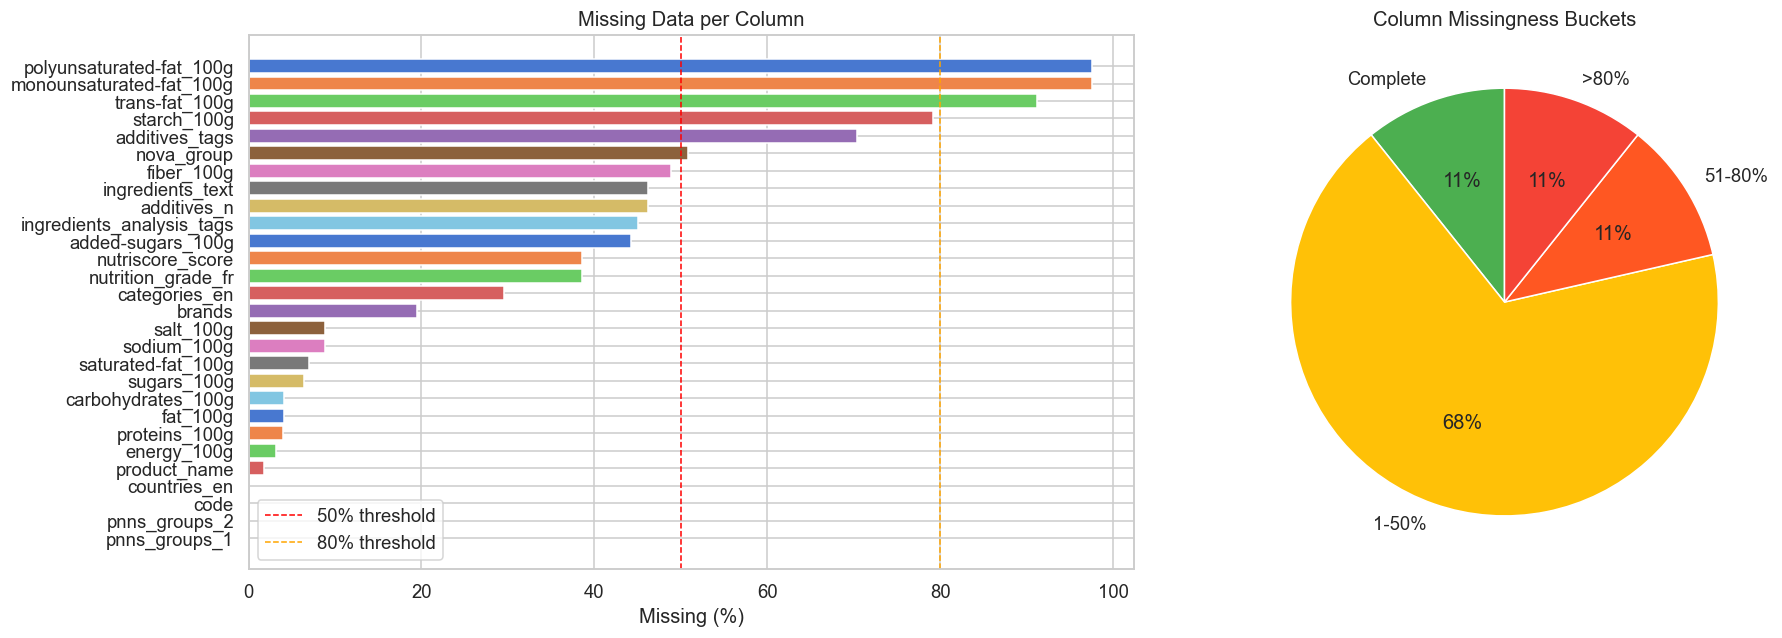

Duplicate rows       : 0
Columns >50% missing : 6
Columns >80% missing : 3


In [17]:
plotter.plot_missingness_overview(df)

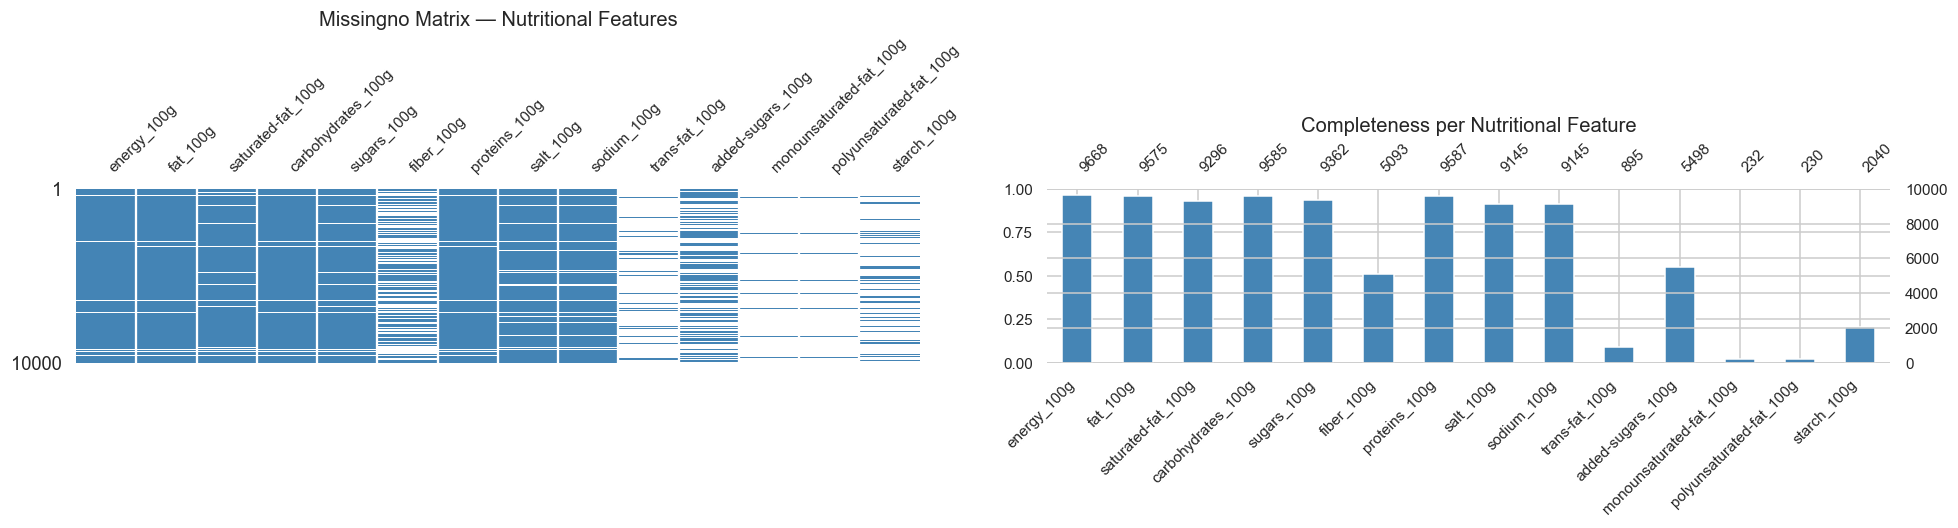

In [18]:
plotter.plot_missingno_matrix(df, NUTRIENT_COLS)

The dataset shows moderate overall data quality, with most columns having 1–50% missingness, while a few key fields such as `additives_tags` and `nova_group` have much higher missing values and may need imputation or exclusion. Overall, the core nutritional variables appear relatively complete, making the dataset usable for modeling after targeted cleaning and preprocessing.

## 4. Target Variable Analysis: Nutritional Quality and Processing Level

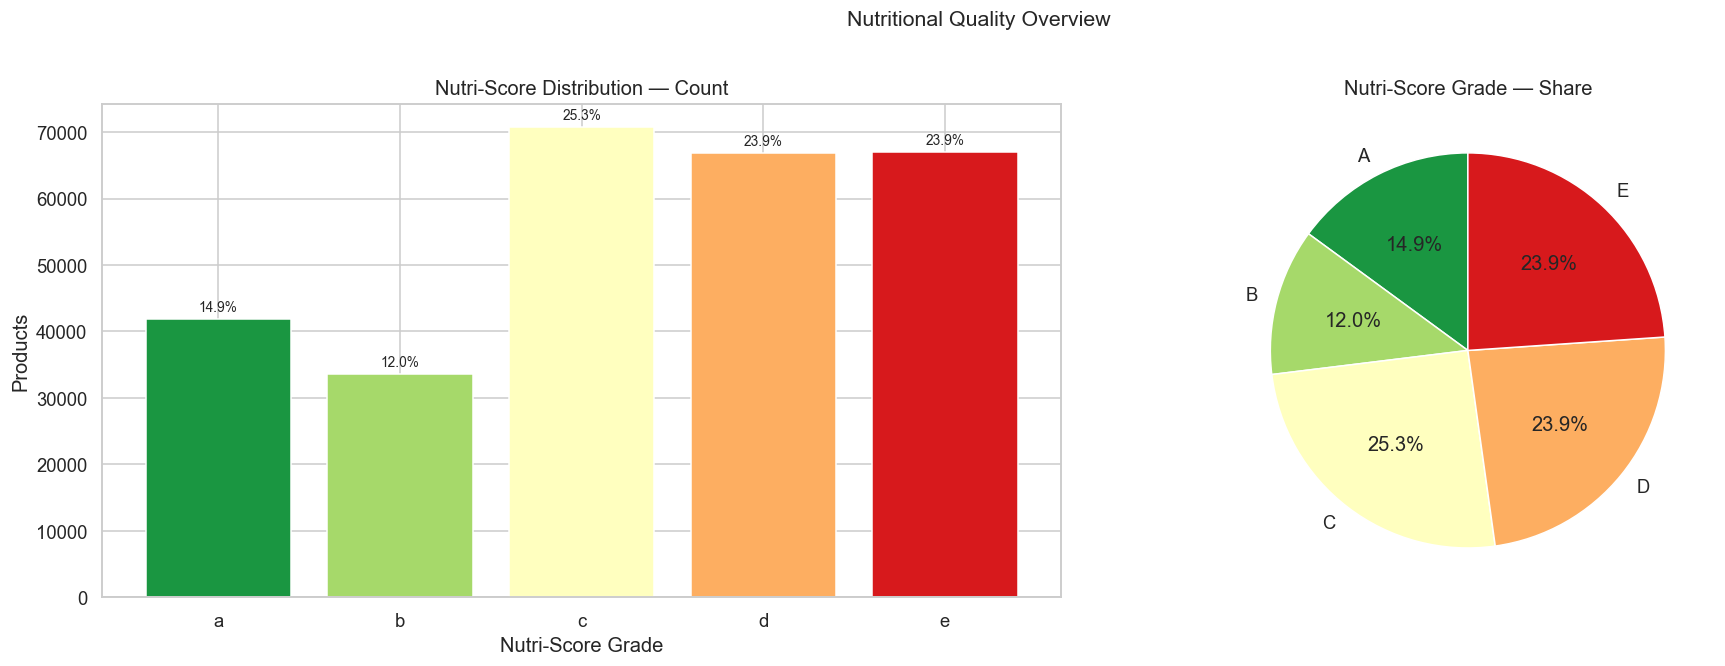

Nutri-Score coverage: 61.5% of loaded rows


In [19]:
plotter.plot_nutriscore_overview(df)

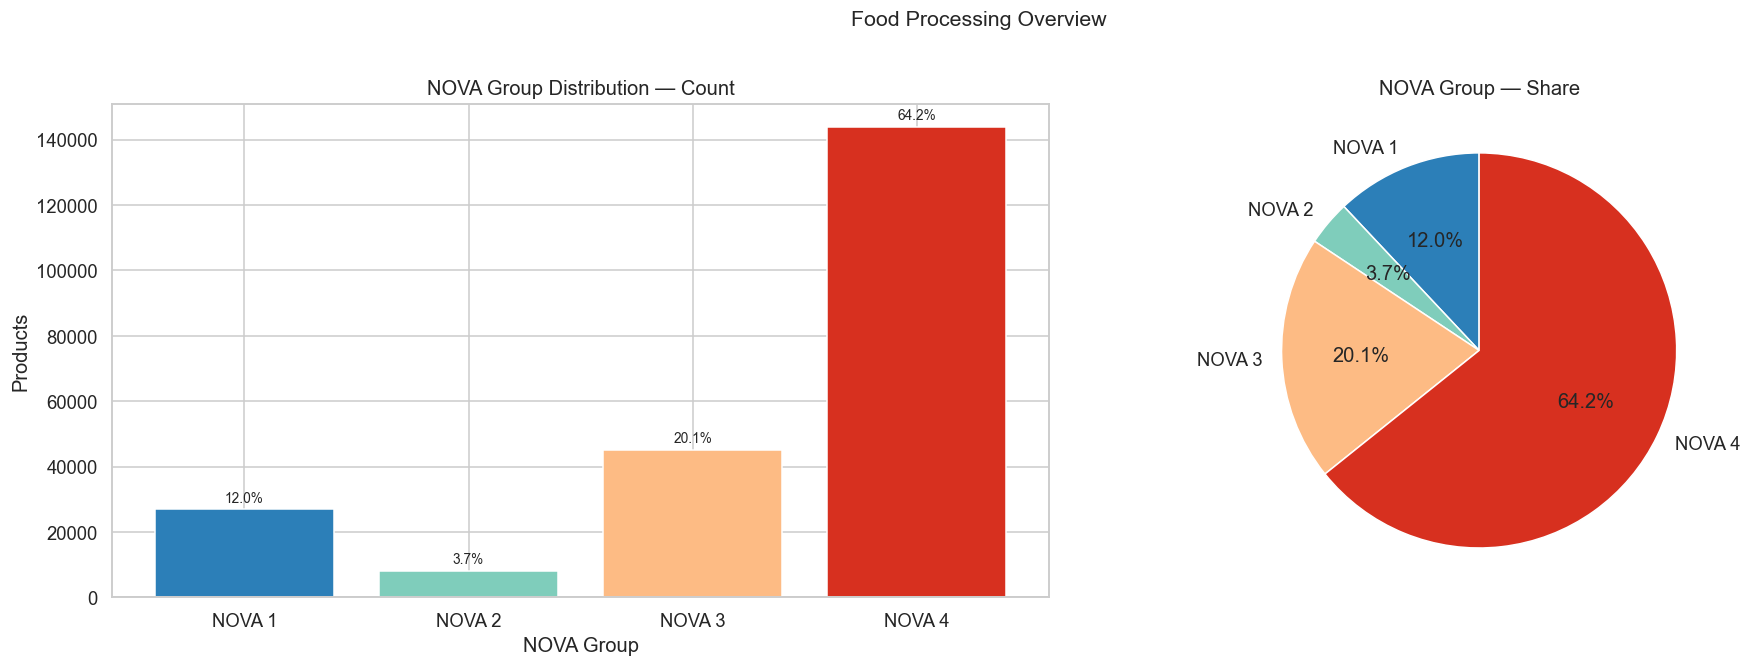

NOVA coverage: 49.1% of loaded rows


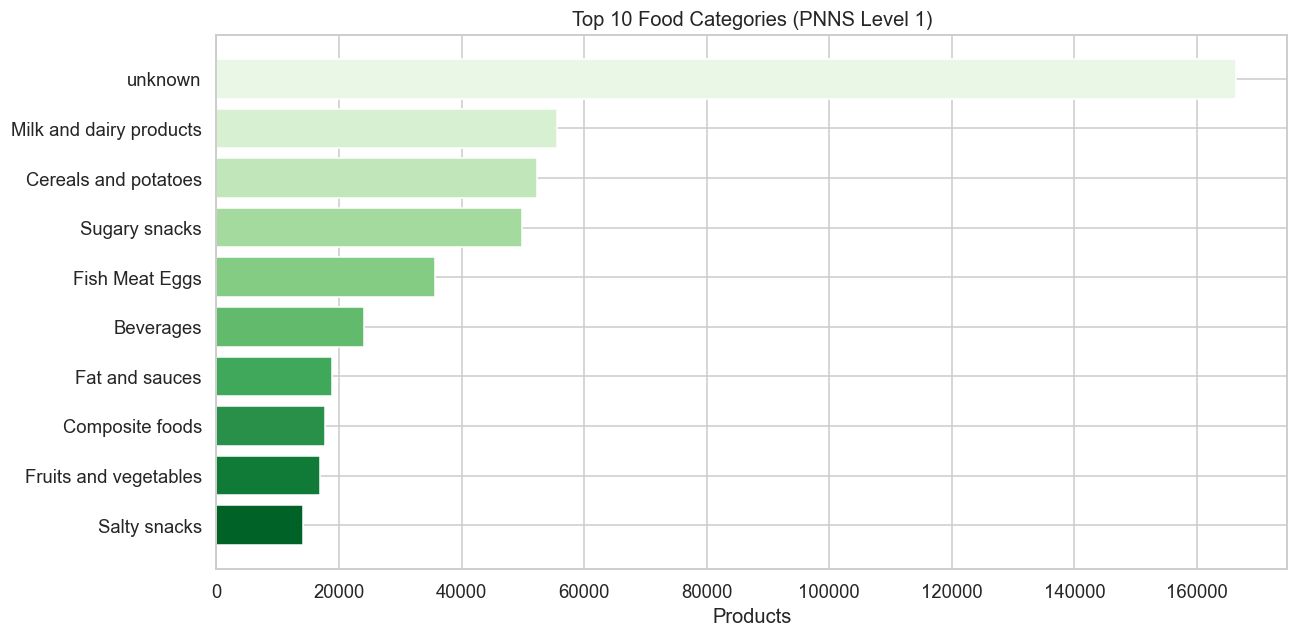

In [20]:
plotter.plot_nova_overview(df)
plotter.plot_category_overview(df)

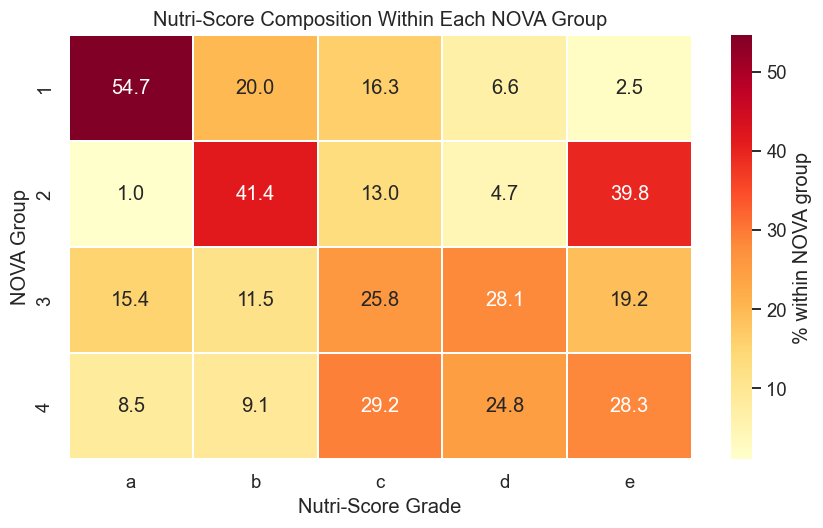

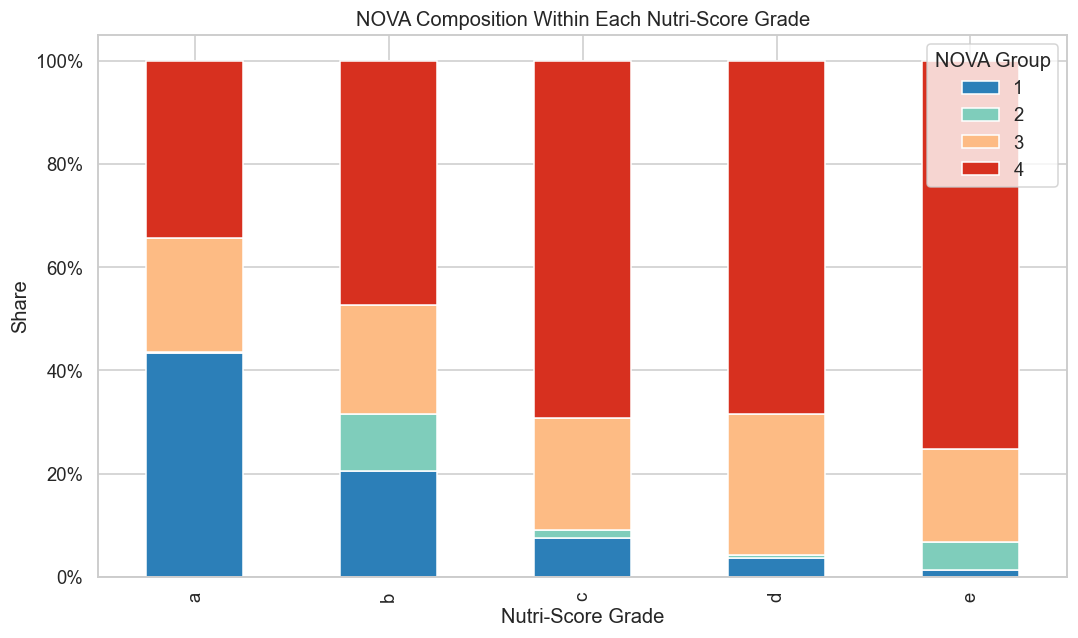

In [21]:
plotter.plot_nova_nutriscore_heatmap(df)
plotter.plot_nova_nutriscore_stacked_share(df)

The target variable analysis shows that the dataset captures both nutritional quality and food processing level in a meaningful way. Nutri-Score grades are fairly distributed, with C being the most common, followed by D, while A and E also appear in substantial proportions, indicating a good mix of healthier and less healthy products. In contrast, the NOVA classification is strongly dominated by NOVA 4, showing that most products in the dataset are ultra-processed foods, while minimally processed items are much less common. The category distribution, led by cereals, potatoes, dairy, snacks, and beverages, further reflects the packaged-food nature of the dataset. The heatmap and stacked bar chart reveal an important pattern: NOVA 1 foods are mostly concentrated in Nutri-Score A, whereas NOVA 4 products dominate the lower nutritional grades C, D, and E, although they also appear in some A and B products. This suggests that while better nutritional scores are often associated with lower processing, nutritional quality and processing level are not identical concepts, which makes them valuable complementary target variables for food assessment and machine learning prediction.

## 5. Nutritional Feature Distributions

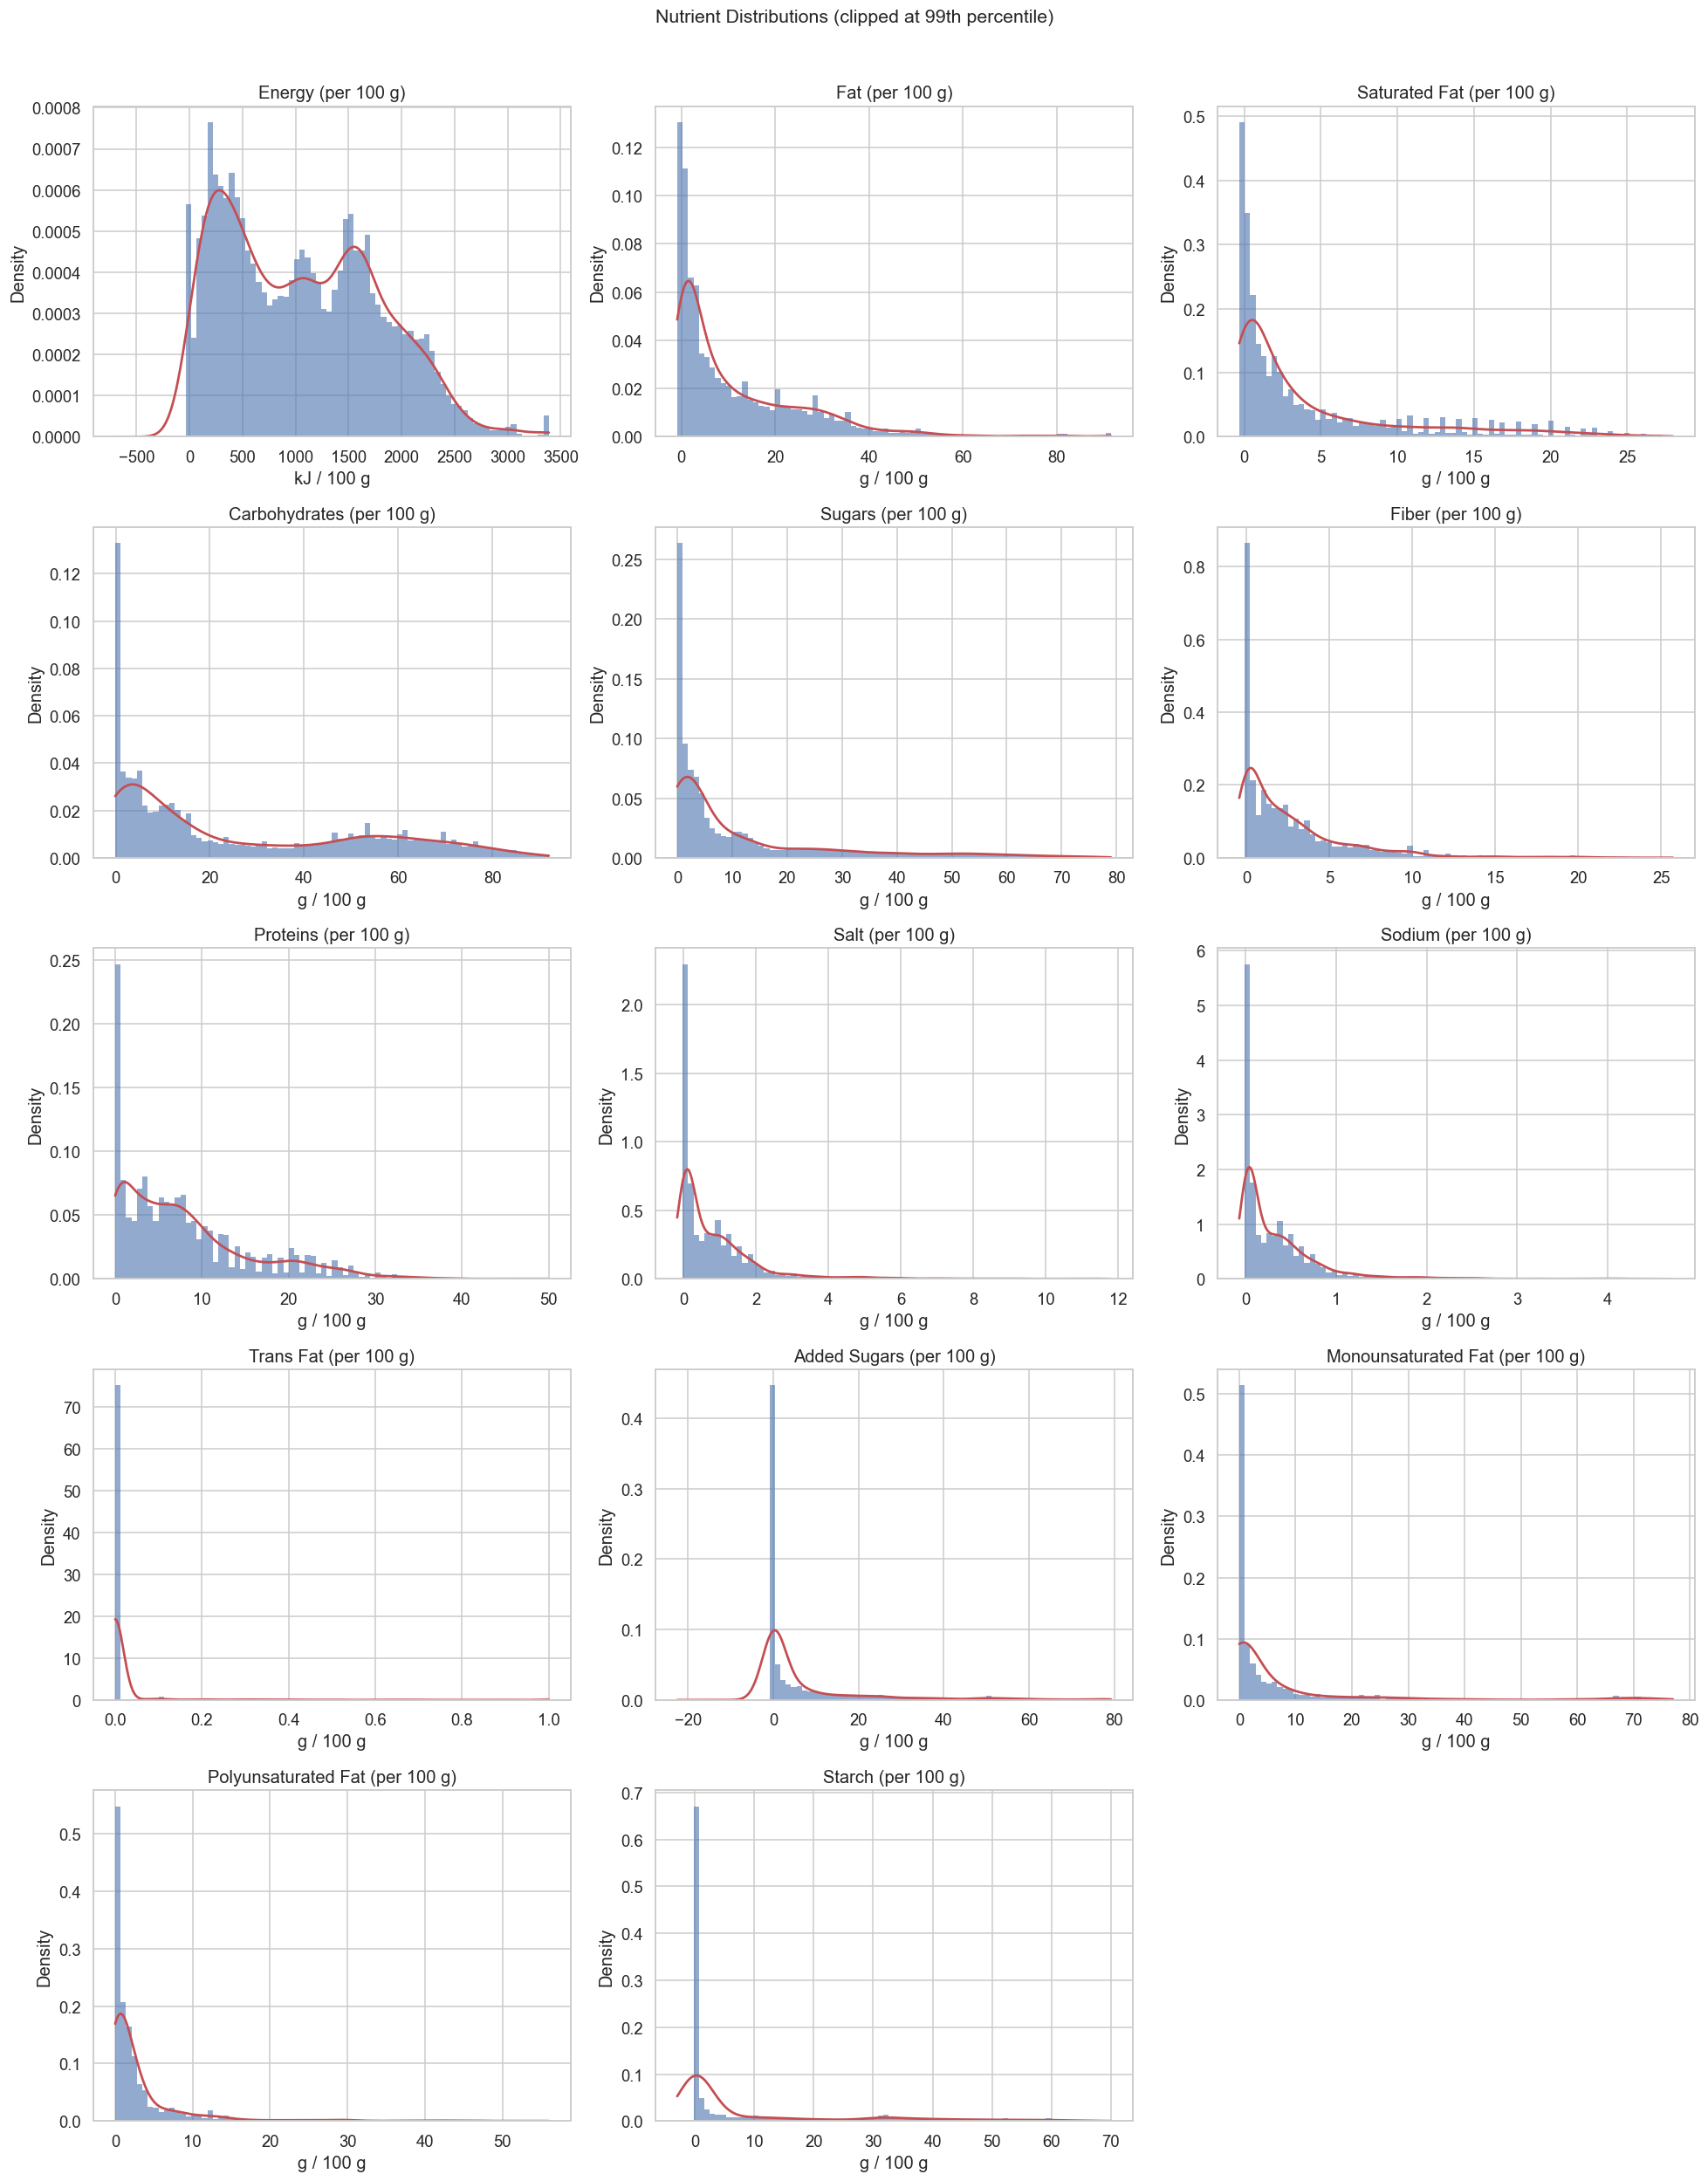

In [23]:
plotter.plot_nutrient_distributions(df, NUTRIENT_COLS)

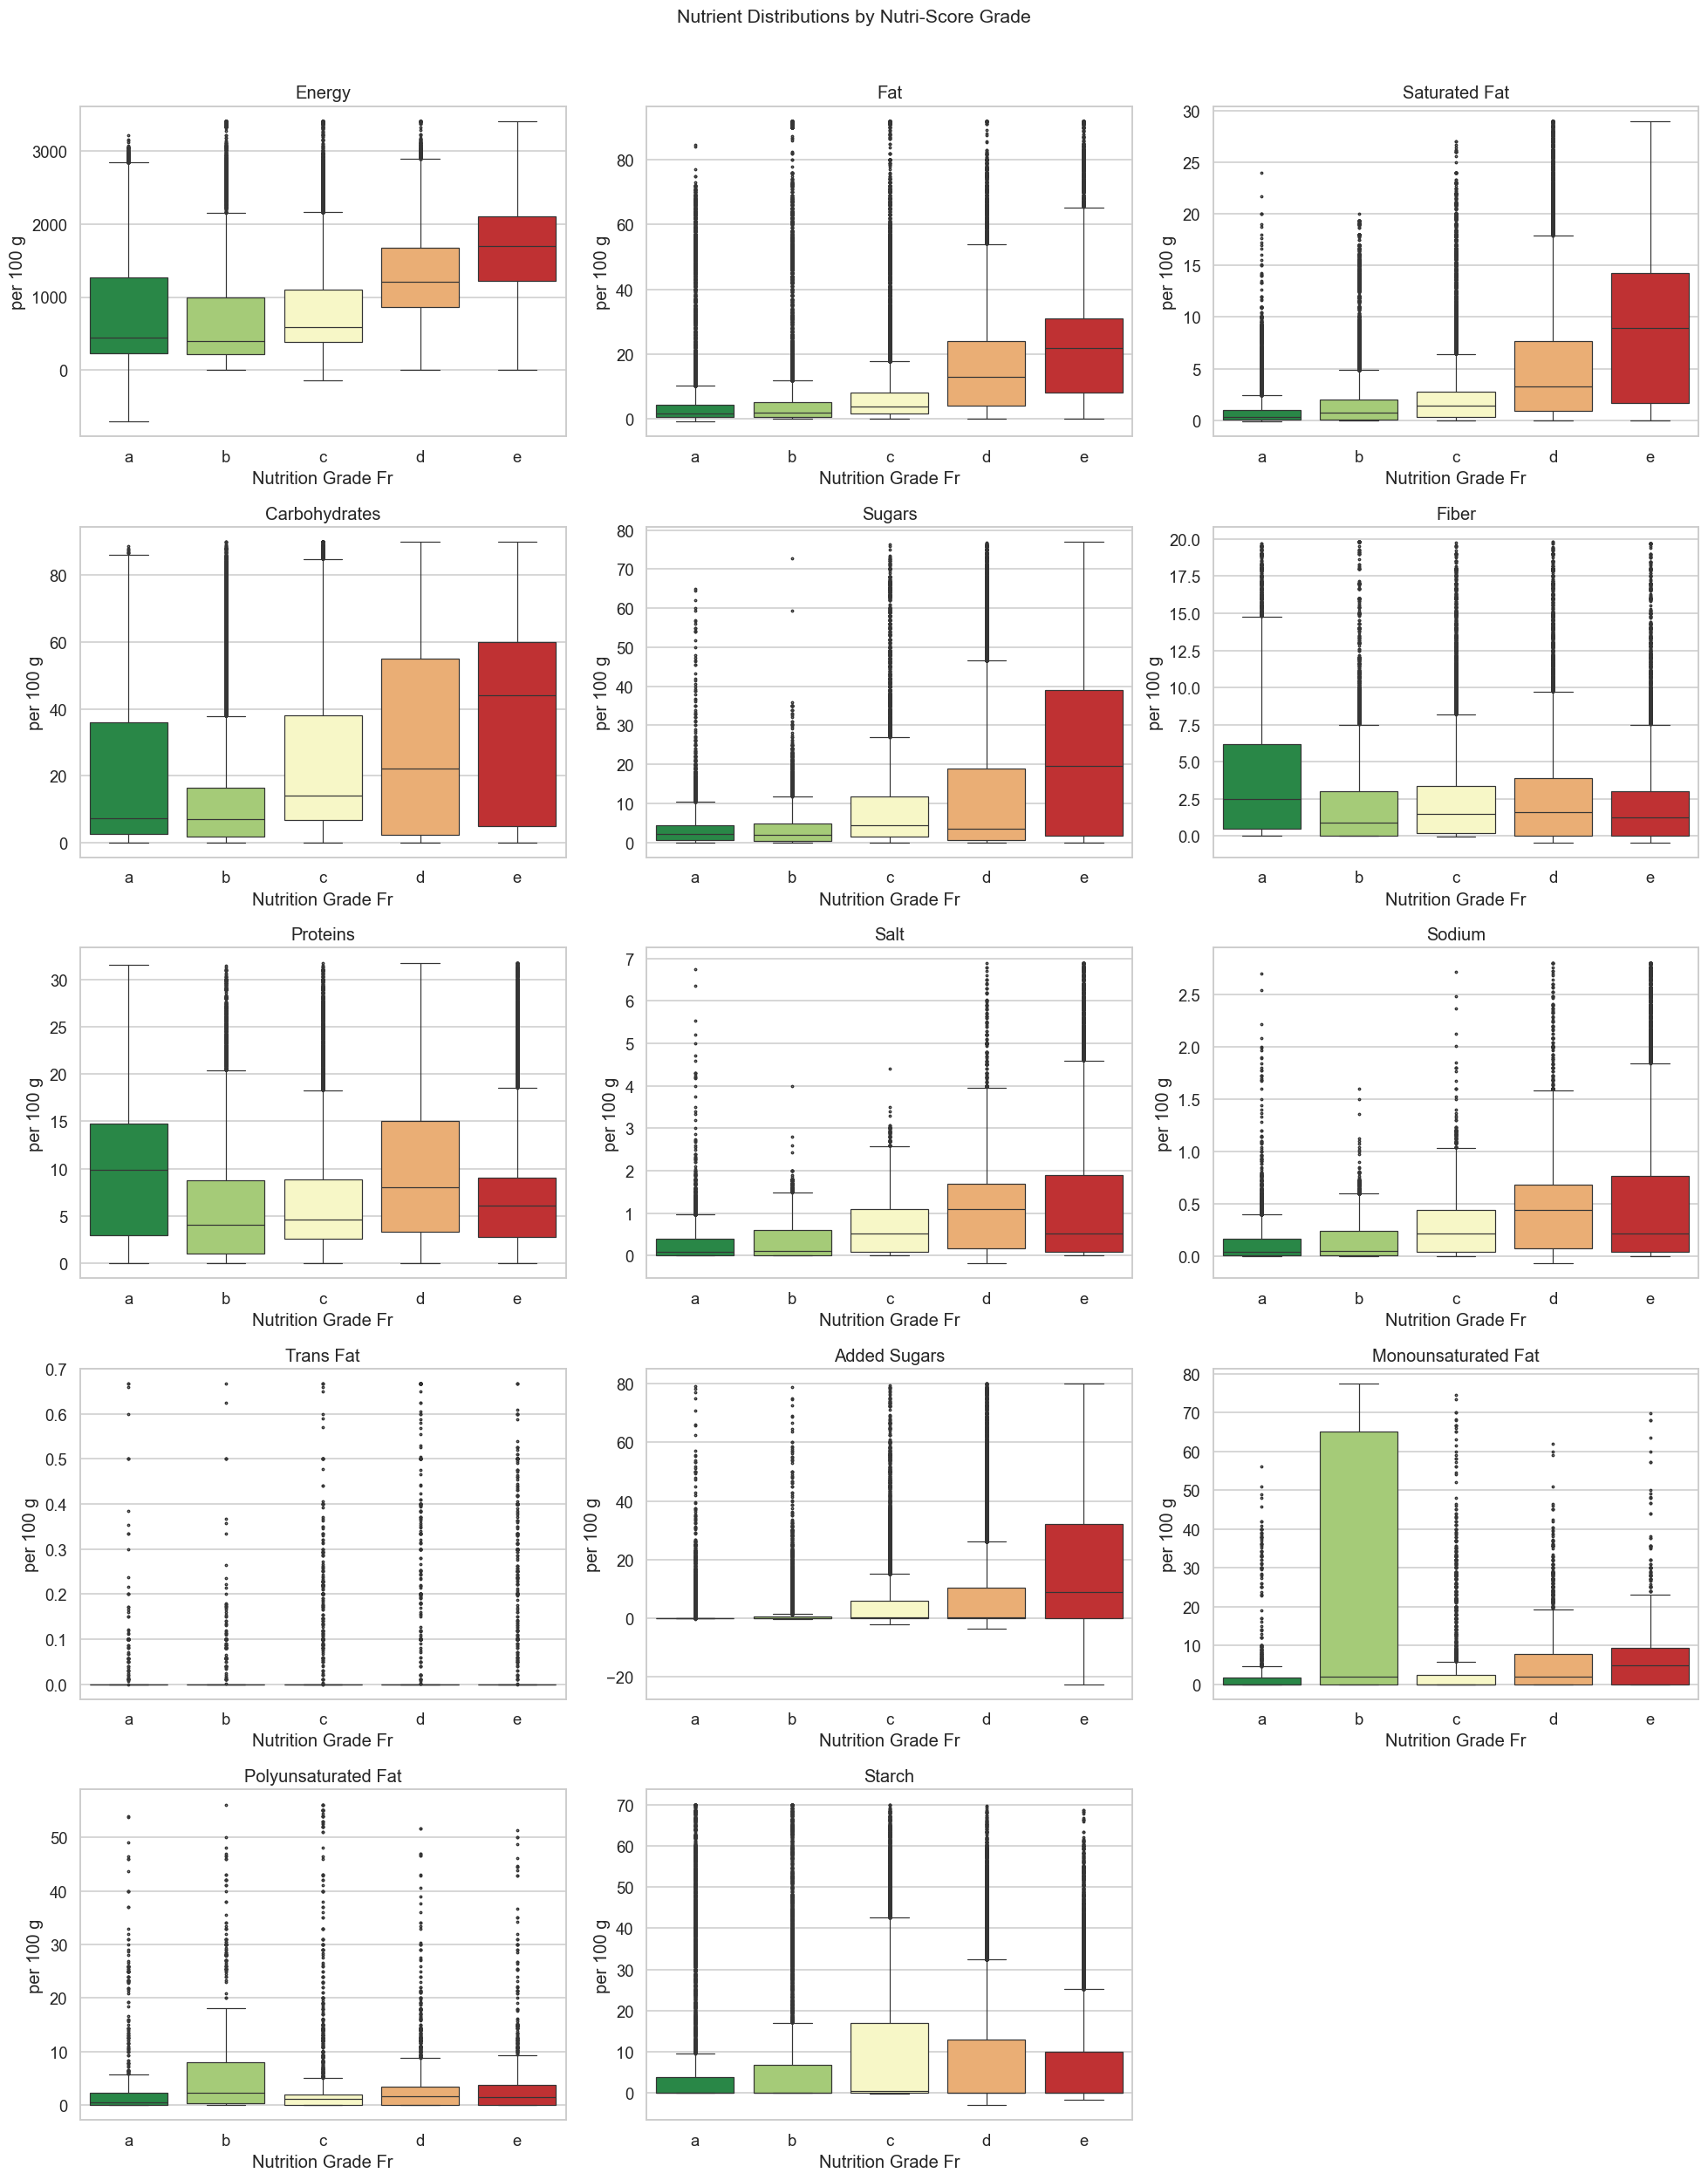

In [24]:
plotter.plot_nutrients_by_group(
    df,
    NUTRIENT_COLS,
    group_col="nutrition_grade_fr",
    order=GRADE_ORDER,
    palette=plotter.grade_palette,
    title="Nutrient Distributions by Nutri-Score Grade",
)

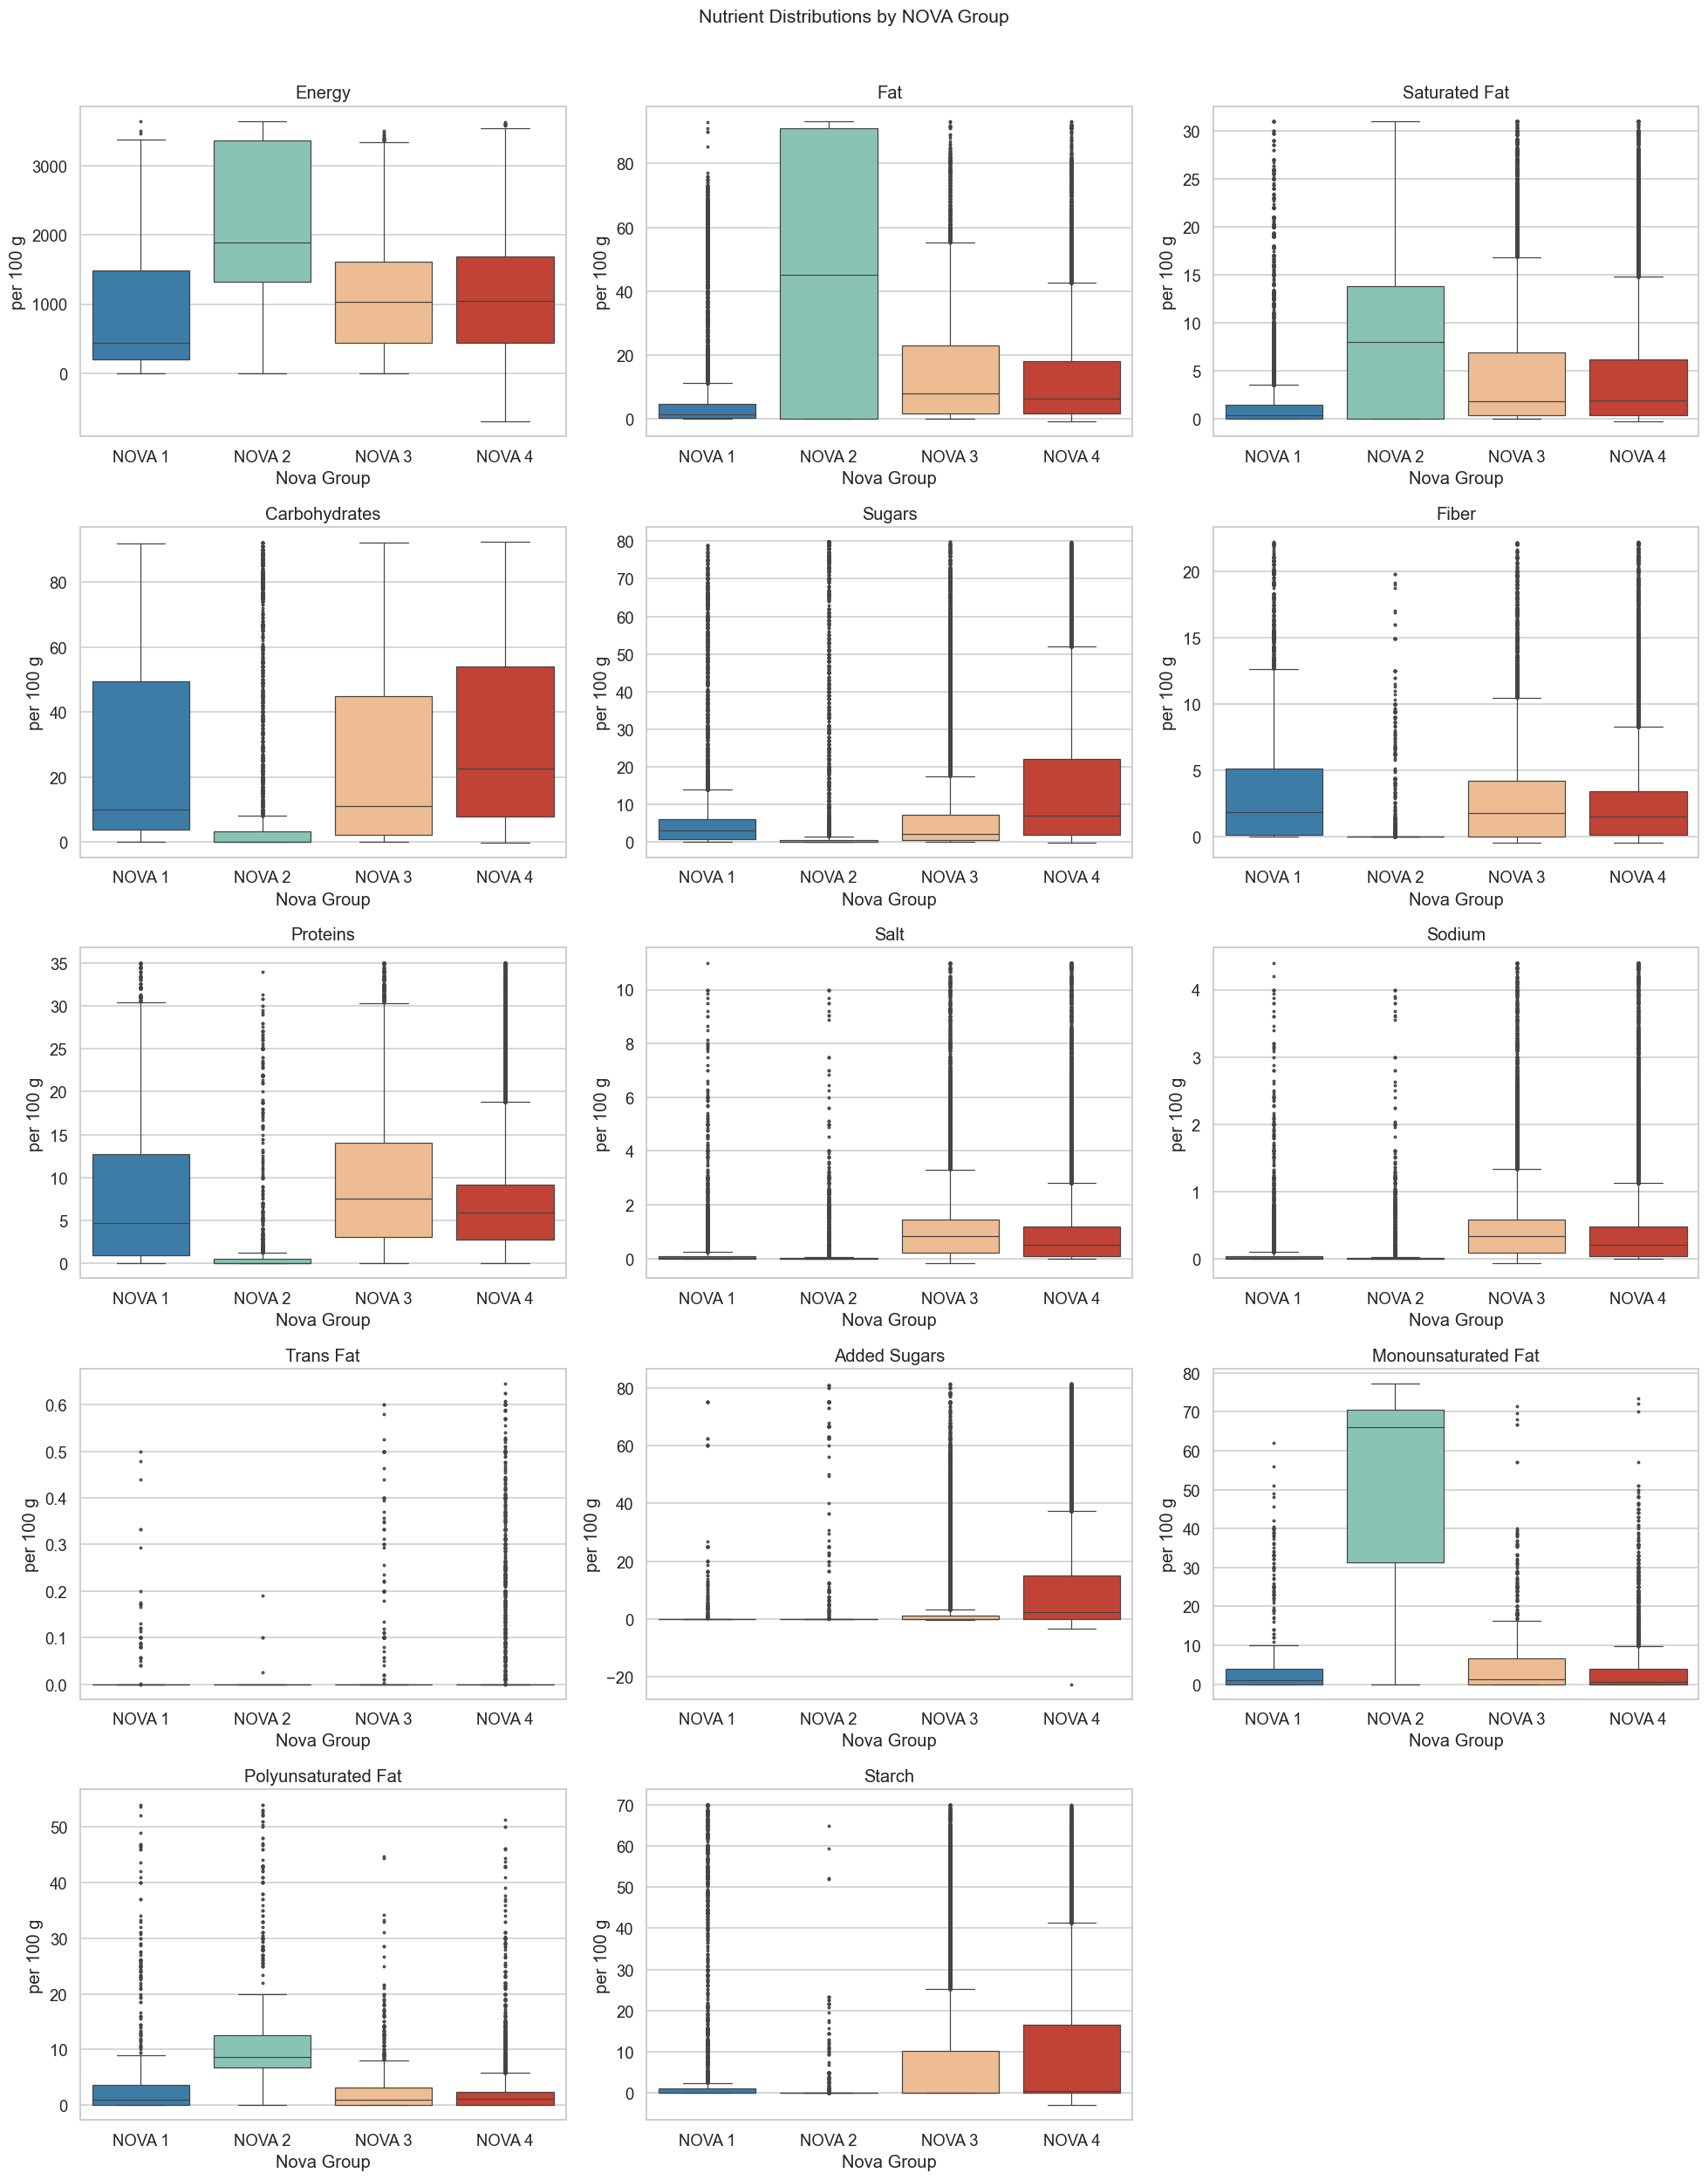

In [25]:
plotter.plot_nutrients_by_group(
    df,
    NUTRIENT_COLS,
    group_col="nova_group",
    order=NOVA_ORDER,
    palette=plotter.nova_palette,
    title="Nutrient Distributions by NOVA Group",
)

The nutritional feature distributions show that most nutrient variables are right-skewed, with many products clustered at lower values and a smaller number of products exhibiting very high amounts, especially for `fat`, `saturated fat`, `sugars`, `salt`, and `sodium`. Across Nutri-Score grades, poorer grades generally correspond to higher median levels of energy, fat, saturated fat, sugars, salt, and sodium, while better grades tend to show relatively higher fiber and more moderate nutrient profiles. A similar trend appears across NOVA groups, where more processed foods, particularly NOVA 3 and NOVA 4, display wider variability and higher concentrations of less desirable nutrients, reinforcing the link between processing intensity and nutritional imbalance.

## 6. Correlation and Multicollinearity Analysis

Correlation analysis revealed strong relationships between certain features, particularly between salt and sodium, indicating potential multicollinearity. These relationships are important to consider during feature selection to avoid redundant information in the modeling stage.

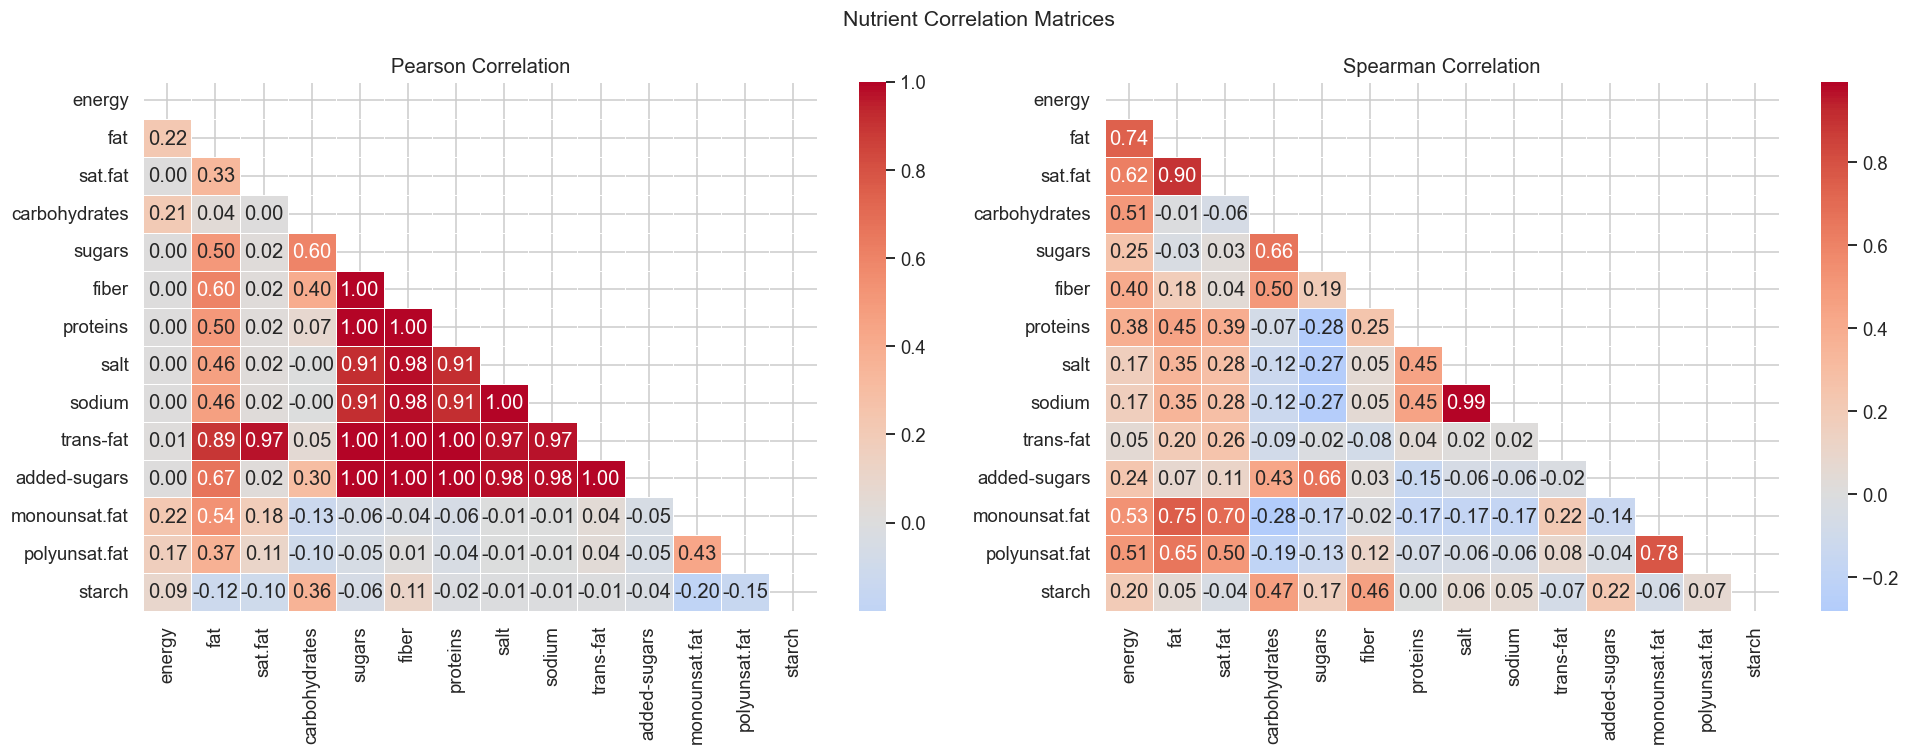

,Feature A,Feature B,Pearson r
0,fat_100g,trans-fat_100g,0.891
1,saturated-fat_100g,trans-fat_100g,0.970
2,sugars_100g,fiber_100g,1.000
3,sugars_100g,proteins_100g,1.000
4,sugars_100g,salt_100g,0.912
5,sugars_100g,sodium_100g,0.912
6,sugars_100g,trans-fat_100g,0.996
7,sugars_100g,added-sugars_100g,1.000
8,fiber_100g,proteins_100g,1.000
9,fiber_100g,salt_100g,0.977


In [26]:
nutrient_data = df[NUTRIENT_COLS].dropna(how="all")
pearson, spearman, high_corr_df = compute_high_correlation_pairs(
    nutrient_data,
    NUTRIENT_COLS,
)

plotter.plot_correlation_matrices(pearson, spearman, NUTRIENT_COLS)

if high_corr_df.empty:
    print("No pairs exceed |r| = 0.85.")
else:
    display(high_corr_df)

The correlation analysis shows several very strong positive relationships among nutritional features, especially between salt and sodium, as well as among sugars, fiber, and proteins, indicating substantial overlap in the information captured by these variables. Such near-perfect Pearson correlations suggest potential multicollinearity, which can distort coefficient-based models and reduce interpretability. Therefore, feature selection, correlation filtering, or dimensionality-reduction techniques can be considered before model training.

## 7. Additive and Ingredient Analysis

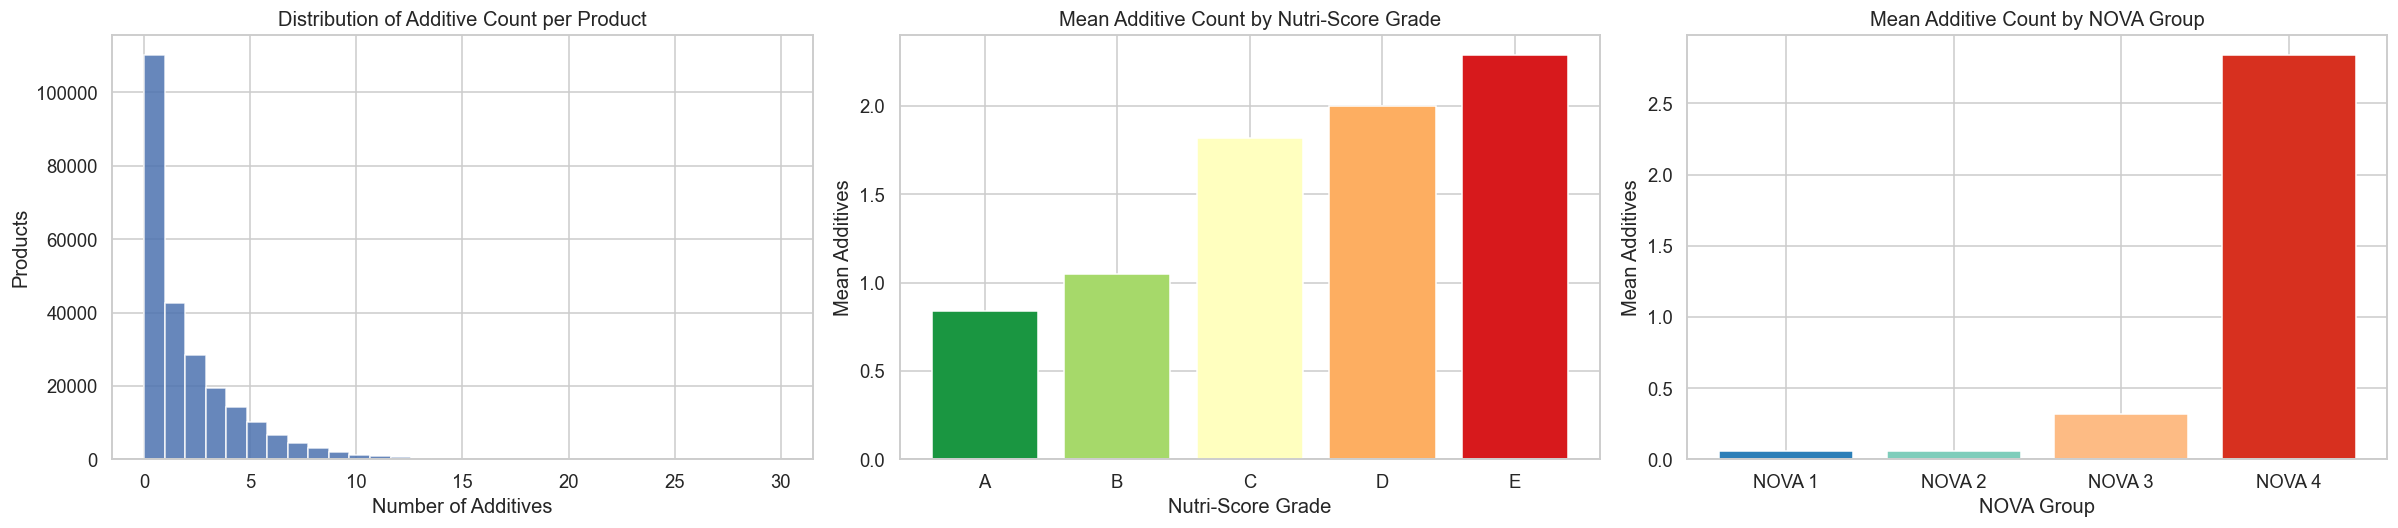

In [27]:
plotter.plot_additives_overview(df)

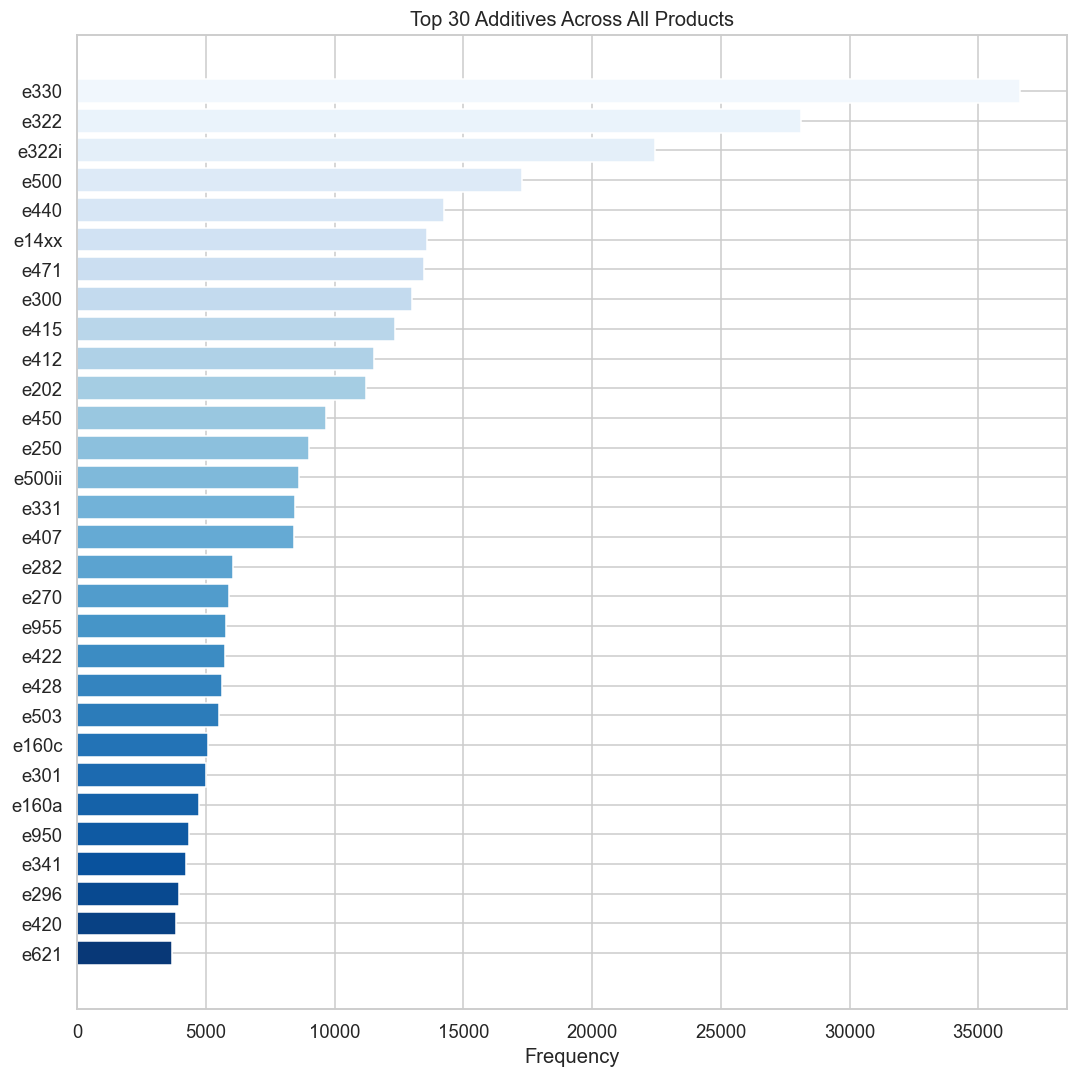

In [28]:
plotter.plot_top_additives(df)

The additive analysis shows that most products contain few or no additives, but the distribution is strongly right-skewed, meaning a smaller subset of products includes a much larger number of additives. Average additive count rises steadily from `Nutri-Score` A to E and is dramatically highest in NOVA 4, indicating that additive use is closely associated with poorer nutritional quality and higher processing intensity. The most frequent additives, such as `e330`, `e322`, `e500`, and `e471`, appear widely across products, suggesting that certain stabilizers, acidity regulators, and emulsifiers are common markers of industrial food formulation.

## 8. Feature Relationships with Nutritional Quality and Processing Level


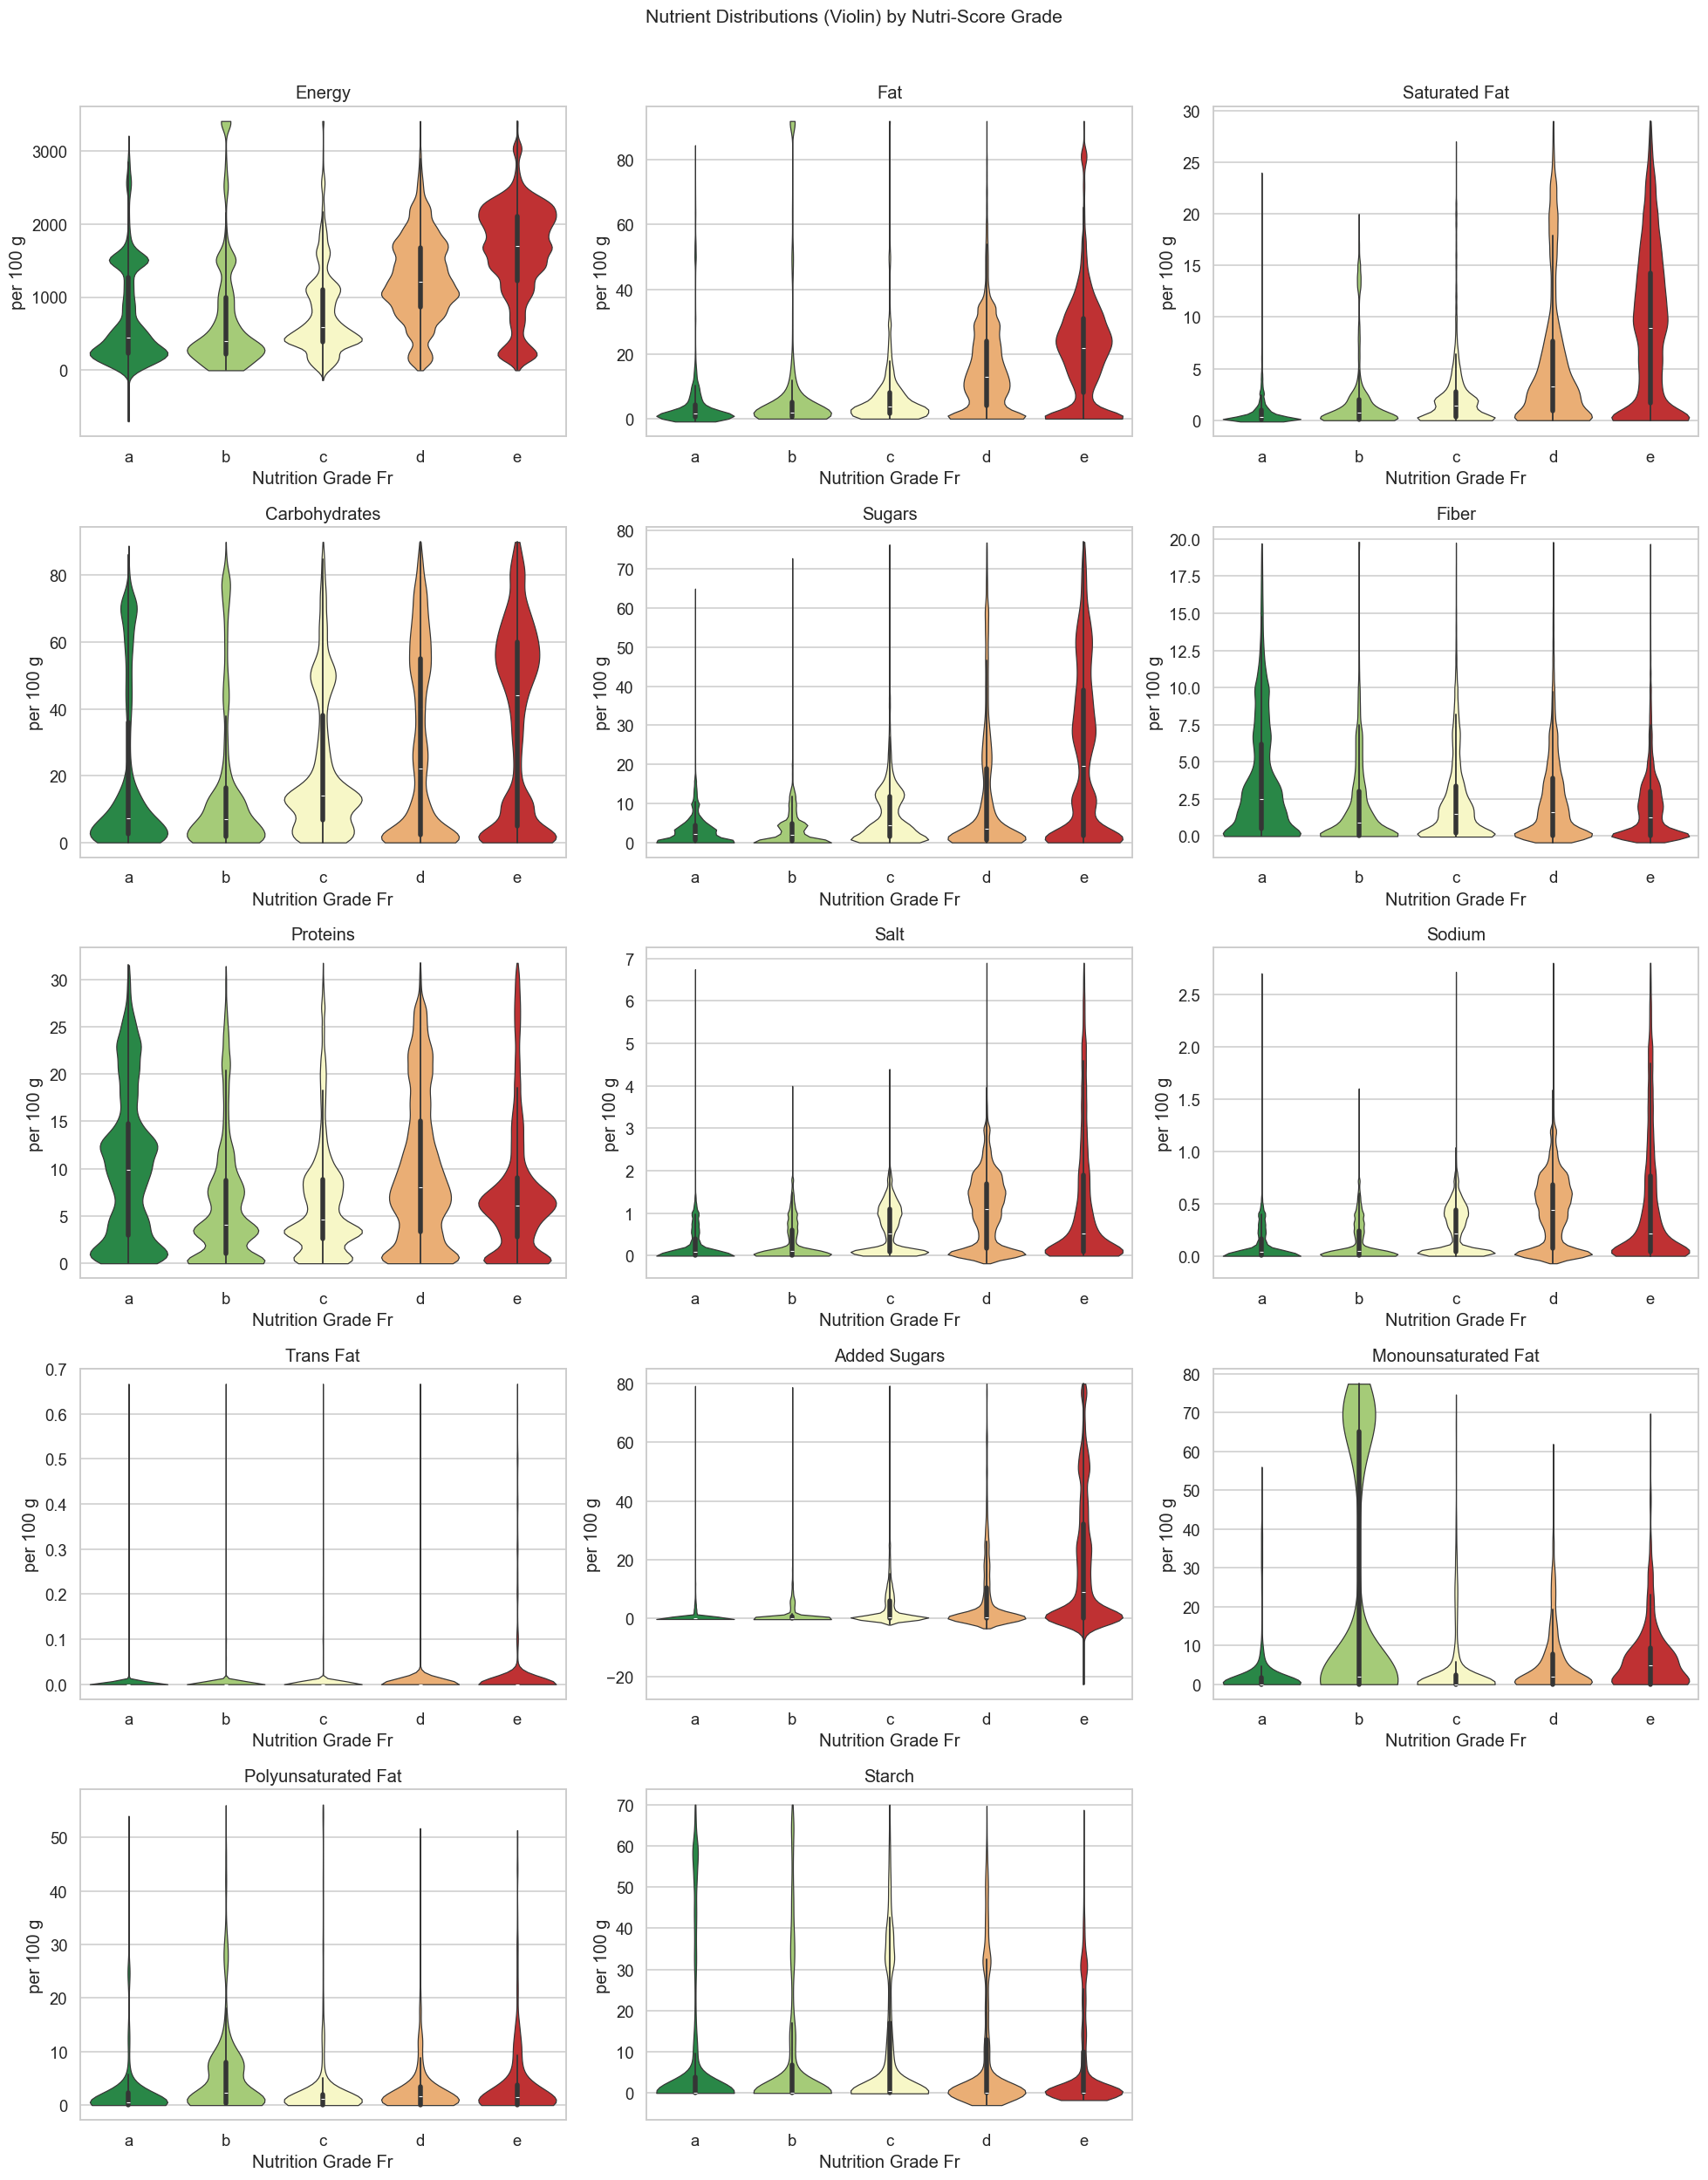

In [29]:
plotter.plot_nutrients_by_group(
    df,
    NUTRIENT_COLS,
    group_col="nutrition_grade_fr",
    order=GRADE_ORDER,
    palette=plotter.grade_palette,
    title="Nutrient Distributions (Violin) by Nutri-Score Grade",
    chart="violin",
)

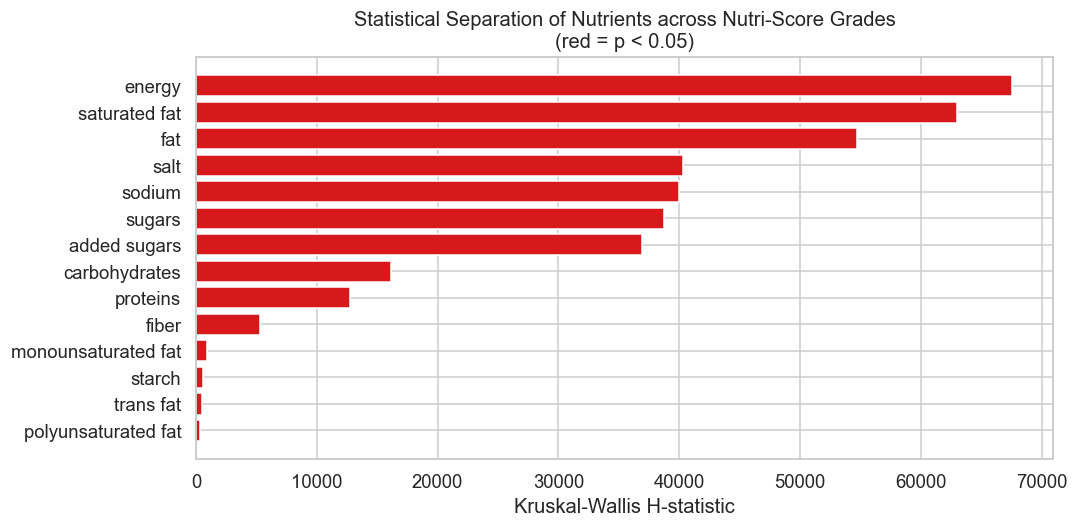

,feature,H-statistic,p-value
0,energy_100g,67564.800,0.000
2,saturated-fat_100g,63031.900,0.000
1,fat_100g,54699.700,0.000
7,salt_100g,40275.700,0.000
8,sodium_100g,40018.400,0.000
4,sugars_100g,38711.300,0.000
10,added-sugars_100g,36884.800,0.000
3,carbohydrates_100g,16150.200,0.000
6,proteins_100g,12740.400,0.000
5,fiber_100g,5310.300,0.000


In [30]:
kw_grade_df = compute_kruskal_summary(
    df,
    NUTRIENT_COLS,
    group_col="nutrition_grade_fr",
    group_order=GRADE_ORDER,
)
plotter.plot_kruskal_summary(
    kw_grade_df,
    "Statistical Separation of Nutrients across Nutri-Score Grades\n(red = p < 0.05)",
)
display(kw_grade_df)

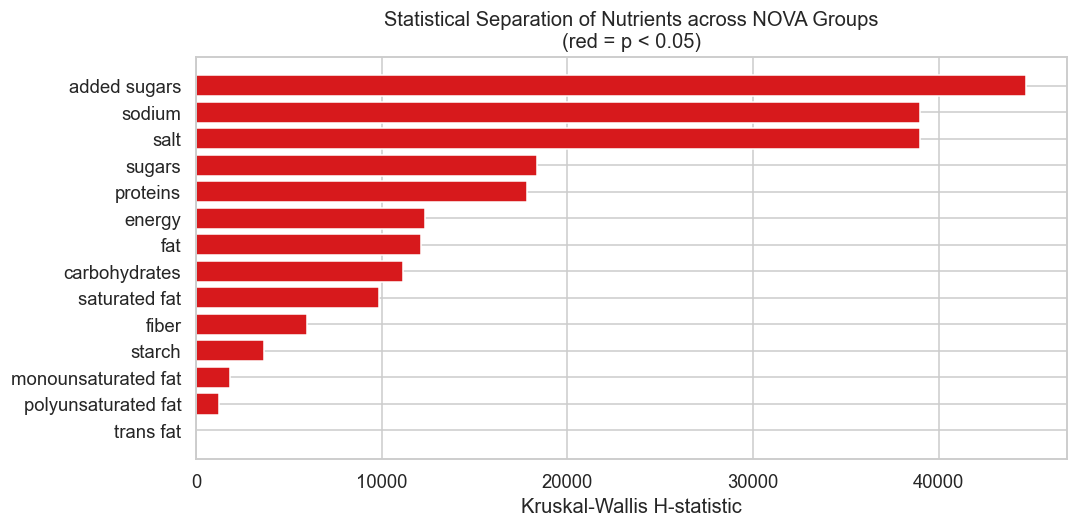

,feature,H-statistic,p-value
10,added-sugars_100g,44699.200,0.000
8,sodium_100g,39010.400,0.000
7,salt_100g,39005.500,0.000
4,sugars_100g,18392.100,0.000
6,proteins_100g,17849.300,0.000
0,energy_100g,12325.800,0.000
1,fat_100g,12133.700,0.000
3,carbohydrates_100g,11165.000,0.000
2,saturated-fat_100g,9860.900,0.000
5,fiber_100g,5995.000,0.000


In [31]:
kw_nova_df = compute_kruskal_summary(
    df,
    NUTRIENT_COLS,
    group_col="nova_group",
    group_order=NOVA_ORDER,
)
plotter.plot_kruskal_summary(
    kw_nova_df,
    "Statistical Separation of Nutrients across NOVA Groups\n(red = p < 0.05)",
)
display(kw_nova_df)

Energy, fat, saturated fat, sugars, salt, and sodium rise as Nutri-Score worsens, while fiber is relatively higher in better grades. Across NOVA groups, salt, sodium, and sugars show the strongest separation, suggesting processing level is strongly linked to industrial formulation. This indicates that these nutrients are likely to be the most useful predictors for both nutritional quality and processing level. It also reinforces that Nutri-Score and NOVA capture overlapping but not identical aspects of food healthfulness.

## 9. Outlier Detection

,feature,outliers,outlier_pct
9,trans-fat_100g,161,0.400
7,salt_100g,1408,0.340
8,sodium_100g,1418,0.340
2,saturated-fat_100g,485,0.110
5,fiber_100g,221,0.090
3,carbohydrates_100g,88,0.020
12,polyunsaturated-fat_100g,2,0.020
10,added-sugars_100g,59,0.020
0,energy_100g,91,0.020
1,fat_100g,49,0.010


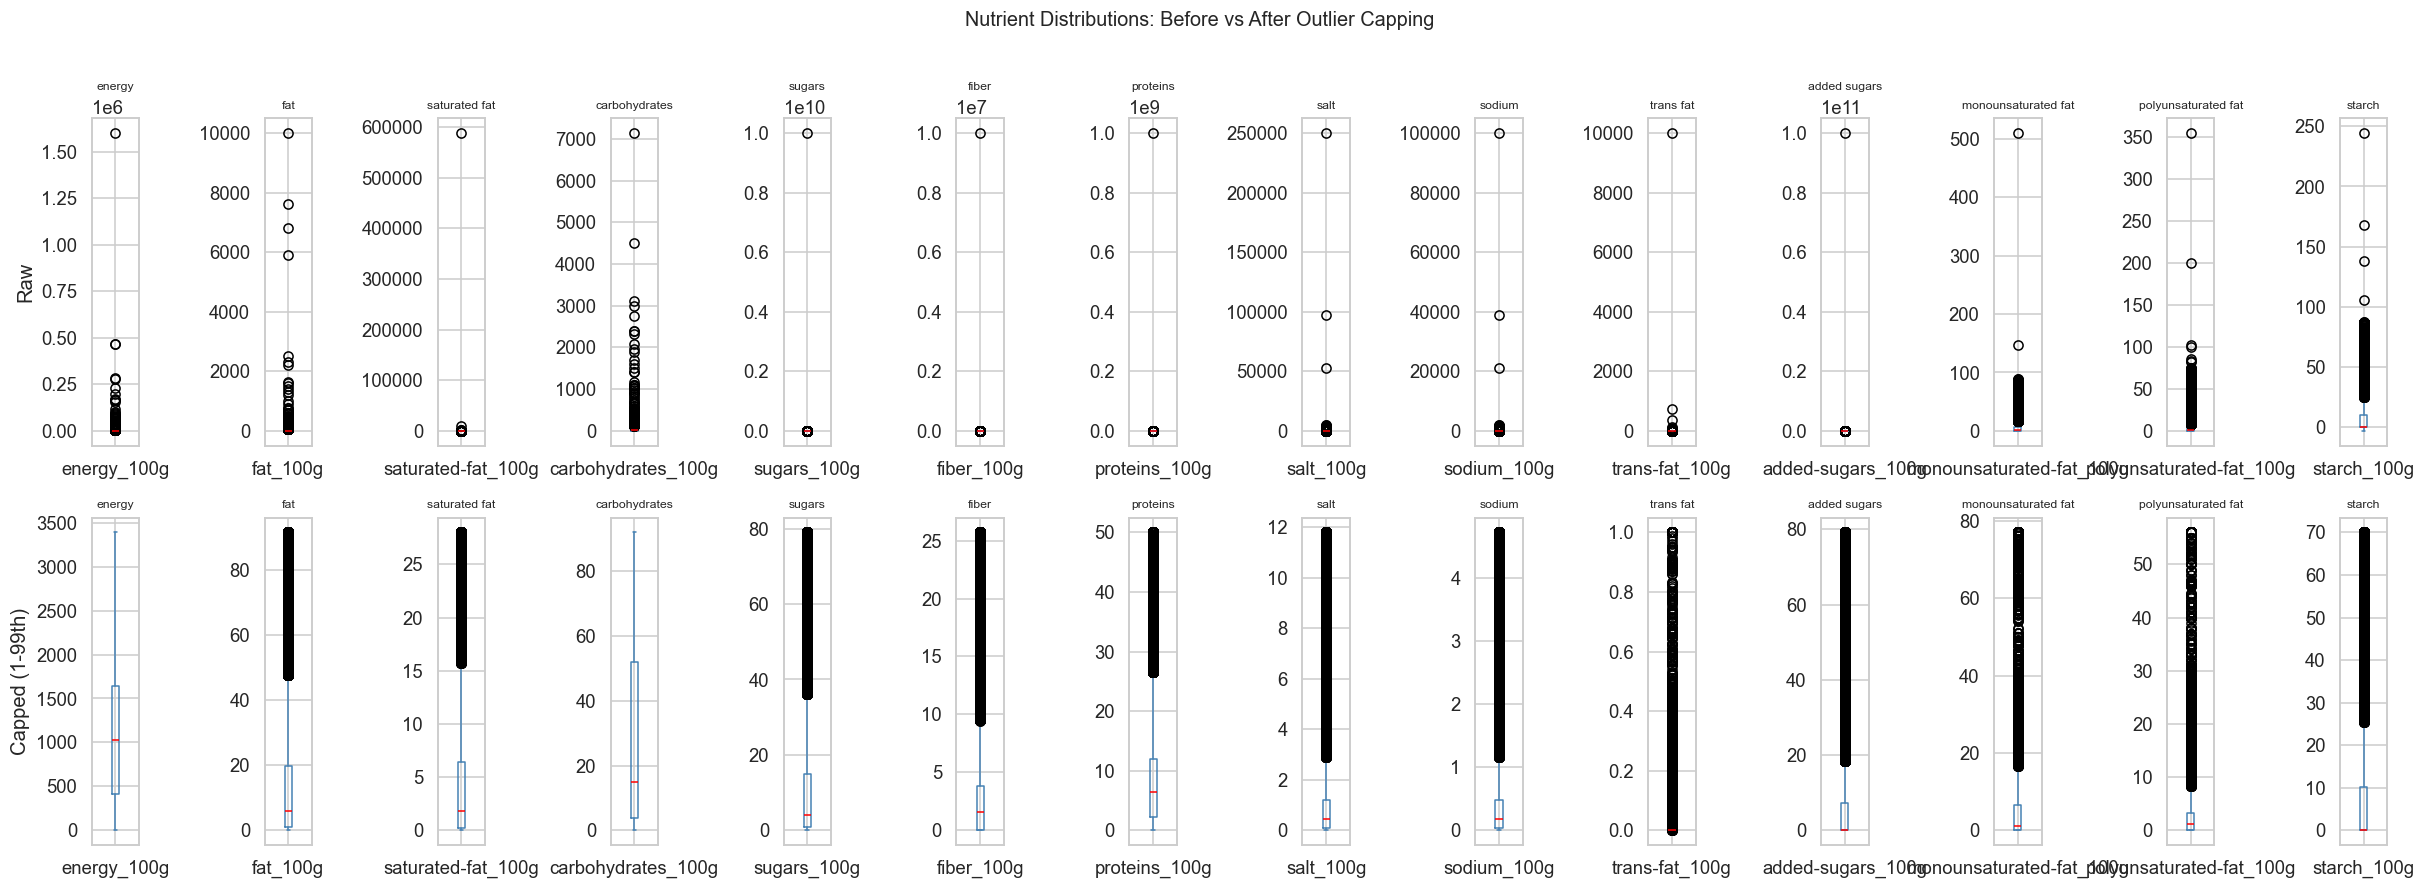

In [32]:
df_capped, out_df = cap_outliers(df, NUTRIENT_COLS)
display(out_df)
plotter.plot_outlier_boxplots(df, df_capped, NUTRIENT_COLS)

The outlier analysis shows that extreme values are present across several nutritional features, with sodium and salt having the highest outlier percentages, followed by fiber and saturated fat. Since these extreme values are relatively rare, percentile-based capping preserves the overall distribution while reducing the influence of anomalous or potentially erroneous observations on model training.

## 10. Geographic and Category Distribution

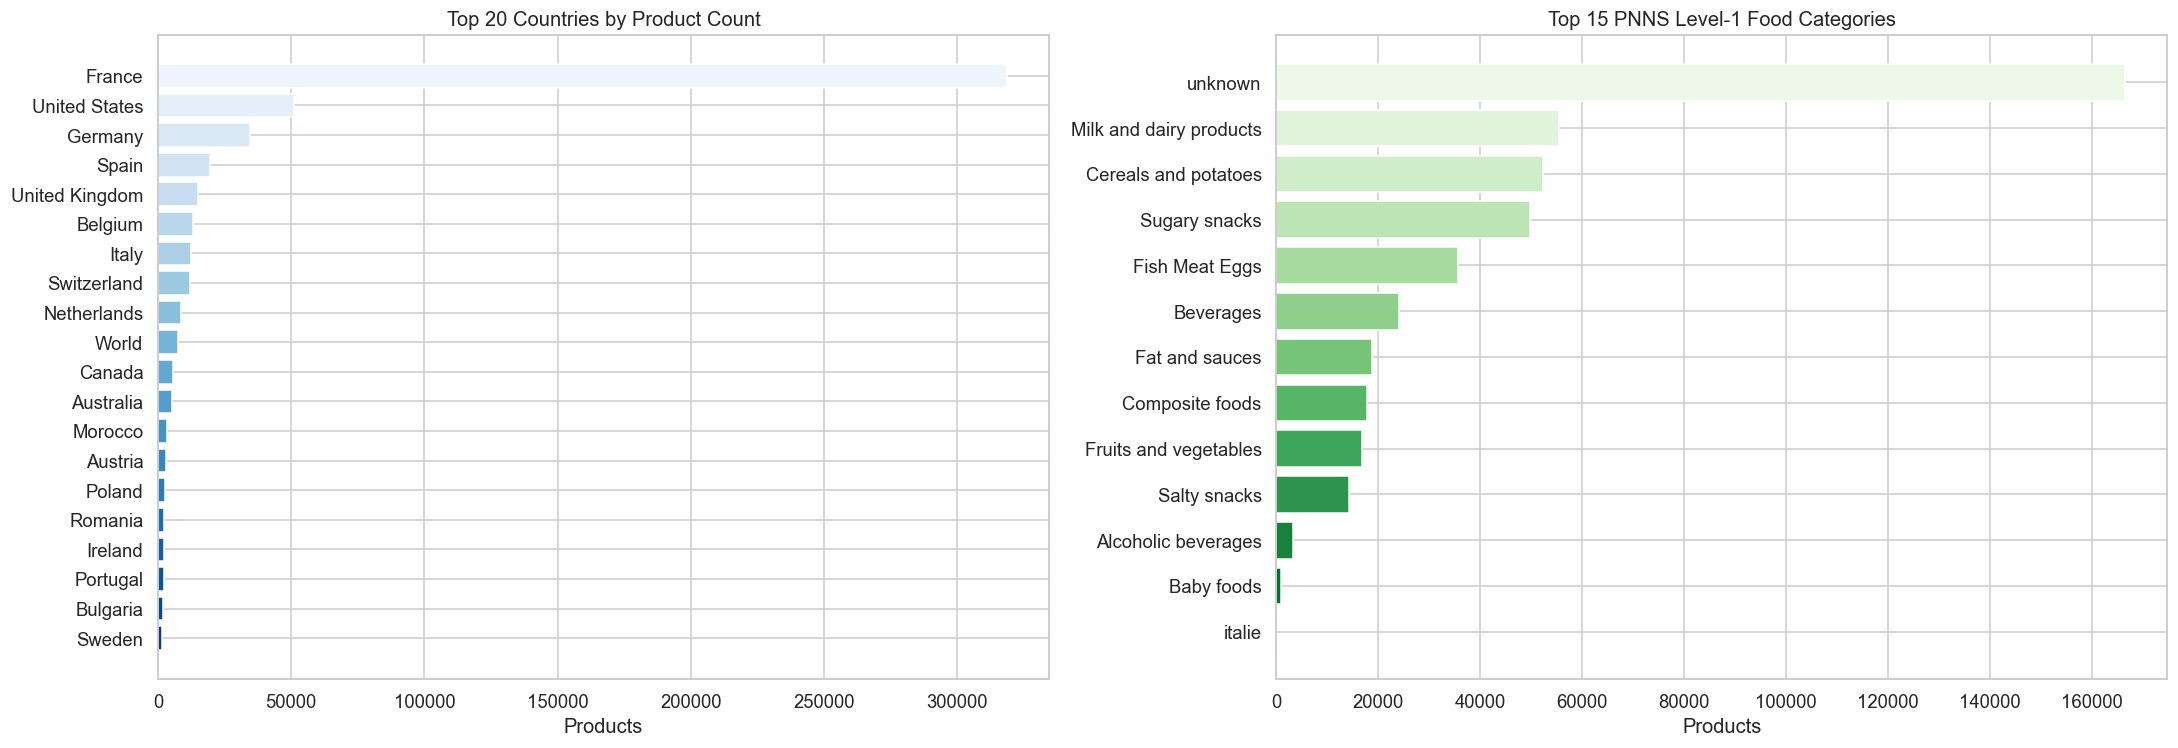

In [33]:
plotter.plot_geo_category_distribution(df)

The geographic distribution shows that the dataset is heavily concentrated in France and the United States, followed by a smaller contribution from several European countries, indicating some regional imbalance in product representation. At the category level, many products fall into unknown, cereals and potatoes, and milk and dairy products, suggesting that packaged staple foods dominate the dataset and that category completeness may need further cleaning for more precise analysis.

## 11. Missing Data Imputation Strategy

Imputation Summary


,feature,global_median,strategy
0,energy_100g,1032.400,global median
1,fat_100g,6.000,global median
2,saturated-fat_100g,1.786,global median
3,carbohydrates_100g,14.800,global median
4,sugars_100g,4.000,global median
5,fiber_100g,1.600,global median
6,proteins_100g,6.400,global median
7,salt_100g,0.450,global median
8,sodium_100g,0.180,global median
9,trans-fat_100g,0.000,global median


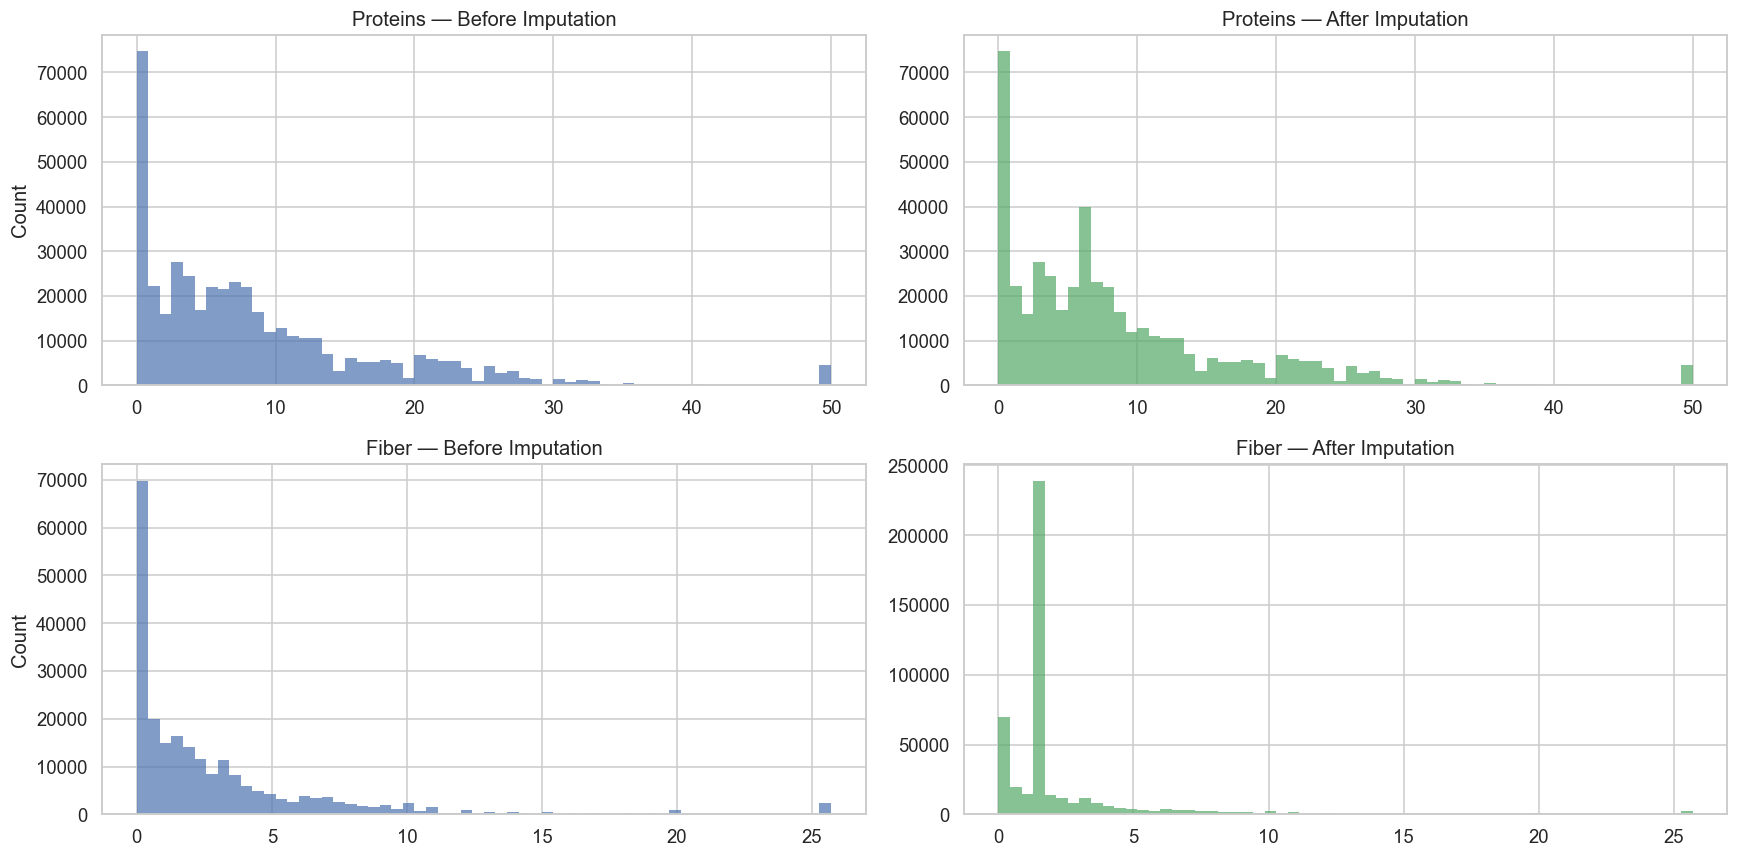

In [34]:
df_imp, imp_df = impute_with_global_median(df_capped, NUTRIENT_COLS)

print("Imputation Summary")
display(imp_df)
plotter.plot_imputation_comparison(df_capped, df_imp, COMPARE_COLS)

Missing numerical values in the core nutritional features were handled using global median imputation, where each column's median is computed from all available non-null values and applied to fill gaps. This approach was applied after outlier capping to ensure that the imputed values are not influenced by extreme observations, preserving the central tendency of each nutrient's distribution across the dataset.

## 12. Basic Data 

To address multicollinearity identified during EDA, redundant features were removed during the data cleaning stage. In particular, `sodium_100g` was dropped because it is deterministically derived from `salt_100g` (salt = sodium × 2.5), and retaining both would introduce perfect multicollinearity. Removing such features helps improve model stability and reduces redundancy in the feature space.

In [35]:
print(f"Rows before cleaning : {len(df_imp):,}")

df_clean = df_imp.copy()

# Step 1: Drop rows where the target variable (nova_group) is missing.
# Rows without a NOVA label cannot contribute to supervised classification.
n_before = len(df_clean)
df_clean = df_clean.dropna(subset=["nova_group"])
n_dropped_nova = n_before - len(df_clean)
print(f"Rows dropped (missing nova_group)   : {n_dropped_nova:,}")

# Step 2: Remove exact duplicate rows to prevent data leakage and inflated metrics.
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
n_dropped_dupes = n_before - len(df_clean)
print(f"Rows dropped (exact duplicates)     : {n_dropped_dupes:,}")

# Step 3: Remove duplicate products by barcode, keeping the first occurrence.
# Duplicate barcodes indicate the same product scanned multiple times.
if "code" in df_clean.columns:
    n_before = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=["code"], keep="first")
    n_dropped_code = n_before - len(df_clean)
    print(f"Rows dropped (duplicate barcodes)   : {n_dropped_code:,}")

# Step 4: Drop sodium_100g — it is deterministically derived from salt_100g
# (salt = sodium × 2.5), so retaining both introduces perfect multicollinearity.
if "sodium_100g" in df_clean.columns:
    df_clean = df_clean.drop(columns=["sodium_100g"])
    print(f"Column dropped (redundant): sodium_100g")

print(f"\nRows after cleaning  : {len(df_clean):,}")
print(f"Total rows removed   : {len(df_imp) - len(df_clean):,}")
print(f"Columns remaining    : {df_clean.shape[1]}")

print("\nNOVA class distribution after cleaning:")
display(
    df_clean["nova_group"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

Rows before cleaning : 455,661
Rows dropped (missing nova_group)   : 231,755
Rows dropped (exact duplicates)     : 0
Rows dropped (duplicate barcodes)   : 0
Column dropped (redundant): sodium_100g

Rows after cleaning  : 223,906
Total rows removed   : 231,755
Columns remaining    : 27

NOVA class distribution after cleaning:


,count
nova_group,
1,26882
2,8218
3,44957
4,143849


## 13. Save and Clean-Up

In [36]:
# create (if not already exists) directory for the processed data
os.makedirs("dataset/processed", exist_ok=True)

# ensure our target variable is correct type
df_clean["nova_group"] = df_clean["nova_group"].astype(int)

# verify final dataset shape and columns
print("Final dataset shape:", df_clean.shape)
print("Columns:", sorted(df_clean.columns.tolist()))

# rename hyphenated columns to underscores for compatibility
df_clean = df_clean.rename(columns={
    "saturated-fat_100g": "saturated_fat_100g",
    "trans-fat_100g": "trans_fat_100g",
    "added-sugars_100g": "added_sugars_100g",
    "monounsaturated-fat_100g": "monounsaturated_fat_100g",
    "polyunsaturated-fat_100g": "polyunsaturated_fat_100g",
})

# barcodes are identifiers, not numbers — store as string to avoid PyArrow overflow
if "code" in df_clean.columns:
    df_clean["code"] = df_clean["code"].astype(str)

# save cleaned dataset
output_path = "dataset/processed/open_food_facts_cleaned.parquet"
df_clean.to_parquet(output_path, index=False)

# confirmation
print(f"\nSaved to: {output_path}")
print(f"Parquet columns ({len(df_clean.columns)}): {sorted(df_clean.columns.tolist())}")

# verify new feature columns are present
expected_new = ["trans_fat_100g", "added_sugars_100g", "monounsaturated_fat_100g",
                "polyunsaturated_fat_100g", "starch_100g", "nutriscore_score"]
found = [c for c in expected_new if c in df_clean.columns]
missing = [c for c in expected_new if c not in df_clean.columns]
print(f"\nNew feature columns found: {len(found)}/{len(expected_new)} — {found}")
if missing:
    print(f"WARNING — missing columns: {missing}")

Final dataset shape: (223906, 27)
Columns: ['added-sugars_100g', 'additives_n', 'additives_tags', 'brands', 'carbohydrates_100g', 'categories_en', 'code', 'countries_en', 'energy_100g', 'fat_100g', 'fiber_100g', 'ingredients_analysis_tags', 'ingredients_text', 'monounsaturated-fat_100g', 'nova_group', 'nutriscore_score', 'nutrition_grade_fr', 'pnns_groups_1', 'pnns_groups_2', 'polyunsaturated-fat_100g', 'product_name', 'proteins_100g', 'salt_100g', 'saturated-fat_100g', 'starch_100g', 'sugars_100g', 'trans-fat_100g']

Saved to: dataset/processed/open_food_facts_cleaned.parquet
Parquet columns (27): ['added_sugars_100g', 'additives_n', 'additives_tags', 'brands', 'carbohydrates_100g', 'categories_en', 'code', 'countries_en', 'energy_100g', 'fat_100g', 'fiber_100g', 'ingredients_analysis_tags', 'ingredients_text', 'monounsaturated_fat_100g', 'nova_group', 'nutriscore_score', 'nutrition_grade_fr', 'pnns_groups_1', 'pnns_groups_2', 'polyunsaturated_fat_100g', 'product_name', 'proteins_100g

Rows missing the target variable `nova_group` were removed first, as they cannot contribute to supervised model training. Exact duplicate rows and barcode-level duplicate product entries were then eliminated to prevent data leakage and overfitting. Finally, `sodium_100g` was dropped as a redundant feature since it is deterministically derived from `salt_100g` (salt = sodium × 2.5), and retaining both would introduce perfect multicollinearity into the feature set. The resulting cleaned dataframe `df_clean` is the final output will be passed to downstream modeling notebooks.

## Exploratory Data Analysis Summary

- The dataset is usable for modeling after preprocessing, with most variables showing low to moderate missingness, while a few fields such as additives and NOVA-related columns have substantially higher missing values.

- Nutri-Score is fairly distributed across classes, with C being the most common grade, providing a reasonable target balance for nutritional quality prediction.

- NOVA group is highly imbalanced toward NOVA 4, indicating that the dataset is dominated by ultra-processed foods.

- Nutritional variables such as fat, saturated fat, sugars, salt, and sodium are generally right-skewed, with many low-to-moderate values and a small number of extreme observations.

- Poorer Nutri-Score grades tend to have higher energy, fat, saturated fat, sugars, salt, and sodium, while better grades are relatively associated with higher fiber.

- Across NOVA groups, the strongest separation is observed for salt, sodium, and sugars, showing that processing level is closely tied to industrial formulation.

- Correlation analysis reveals strong multicollinearity among some nutrient features, especially salt–sodium and several other highly correlated nutrient pairs, suggesting the need for feature selection or dimensionality reduction.

- Outlier detection shows that extreme values are present but relatively rare, and percentile-based capping helps reduce their impact without heavily distorting the data.

- Missing nutritional values were handled using global median imputation, which preserved the overall distributions while filling gaps robustly in skewed variables.

- Additive analysis shows that most products contain few additives, but additive counts increase with worse Nutri-Score and are highest in NOVA 4, reinforcing the connection between additives and ultra-processing.

- The dataset is geographically concentrated in France and the United States, with additional representation from several European countries, which may introduce regional bias.

- Product categories are dominated by unknown, cereals and potatoes, and milk and dairy products, indicating both strong packaged-food representation and some category-label incompleteness.

**Overall, the EDA suggests that the dataset contains strong predictive signals for both nutritional quality and processing level, but it also requires careful handling of missing data, class imbalance, outliers, and multicollinearity before model development.**